In [ ]:
!pip freeze > requirements.txt

## (Symbolic Regression) Experiment2 - Star-Galaxy-Quasar Classification

## Star-Galaxy-Quasar Classification (Experiment 2) using PySR. We are using spectroscopic redshift (z) as input.



In [1]:
# Step 0 — Imports & global configuration

import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
import sympy as sp
from scipy.optimize import minimize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    cohen_kappa_score, confusion_matrix, f1_score,
    precision_recall_fscore_support, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

from pysr import PySRRegressor

warnings.filterwarnings('ignore', category=RuntimeWarning)

RESULTS_DIR = Path('Ex2_SR_SGQ')
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# Modeling knobs
RANDOM_STATE   = 42
# Display order kept at GALAXY -> STAR -> QSO so confusion matrices and
# allowing direct visual comparison between the two encodings.
CLASSES        = ['GALAXY', 'STAR', 'QSO']

# SGQ ordinal encoding: STAR=0 (lowest z), GALAXY=1 (middle z), QSO=2 (highest z).
# Under this monotone-in-z mapping PySR usually finds a simpler s(z) than
# under the GSQ encoding used in the base notebook.
LABEL_TO_ORD   = {'STAR': 0, 'GALAXY': 1, 'QSO': 2}
ORD_TO_LABEL   = {v: k for k, v in LABEL_TO_ORD.items()}

# Ordinal indices arranged in the DISPLAY order from `CLASSES`. Use this
# anywhere sklearn wants `labels=...` so rows/columns of confusion matrices
# and classification reports stay in GALAXY -> STAR -> QSO order regardless
# of the encoding above. Under SGQ this evaluates to [1, 0, 2].
LABEL_ORDER    = [LABEL_TO_ORD[c] for c in CLASSES]
COMPLEXITY_CAP = 10
N_FOLDS        = 5
PYSR_NITER     = 500

# ---- Plot aesthetics ------------------------------------------
PALETTE = {
    'GALAXY': {'color': '#1f4e79', 'marker': 's'},
    'STAR':   {'color': '#d62728', 'marker': 'o'},
    'QSO':    {'color': '#2ca02c', 'marker': '^'},
}
FIGSIZE_SINGLE = (7.0, 5.0)
FIGSIZE_DOUBLE = (13.5, 5.0)

sns.set_style('white')
plt.rcParams.update({
    'figure.dpi':           150, 'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'figure.facecolor':     'white', 'savefig.facecolor':    'white',
    'font.family':          'DejaVu Sans', 'font.size':            11,
    'axes.titlesize':       14, 'axes.titleweight':     'bold',
    'axes.labelsize':       13, 'axes.labelweight':     'normal',
    'axes.spines.top':      True, 'axes.spines.right':    True,
    'axes.spines.bottom':   True, 'axes.spines.left':     True,
    'axes.edgecolor':       'black', 'axes.linewidth':       1.2,
    'xtick.direction':      'in', 'ytick.direction':      'in',
    'xtick.top':            True, 'ytick.right':          True,
    'xtick.major.size':     5.5, 'ytick.major.size':     5.5,
    'xtick.minor.size':     3.0, 'ytick.minor.size':     3.0,
    'xtick.major.width':    1.0, 'ytick.major.width':    1.0,
    'xtick.minor.width':    0.8, 'ytick.minor.width':    0.8,
    'xtick.minor.visible':  True, 'ytick.minor.visible':  True,
    'xtick.labelsize':      11, 'ytick.labelsize':      11,
    'xtick.color':          'black', 'ytick.color':          'black',
    'axes.grid':            False,
    'grid.alpha':           0.25, 'grid.linestyle':       ':', 'grid.color':           '0.5',
    'legend.fontsize':      11, 'legend.framealpha':    0.95,
    'legend.edgecolor':     'black', 'legend.fancybox':      False,
    'lines.linewidth':      2.4, 'lines.markersize':     8,
})


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Step 1 — Load and clean the catalog

Keep only the columns we actually use, standardize the `QUASAR` label to
`QSO`, drop rows missing class or redshift, and map class names to ordinal
integers:

$$y \;=\; \begin{cases} 0 & \text{STAR}\\ 1 & \text{GALAXY}\\ 2 & \text{QSO}\end{cases}$$

The ordinal encoding is what the regression target will use.


In [2]:
CSV_PATH = 'photofeatures_exp2.csv'
df = pd.read_csv(CSV_PATH)
df['class'] = df['class'].astype(str).str.upper().replace({'QUASAR': 'QSO'})
df = df.dropna(subset=['class', 'redshift']).reset_index(drop=True)
df = df[df['class'].isin(CLASSES)].reset_index(drop=True)
df['y_ord'] = df['class'].map(LABEL_TO_ORD).astype(int)
print(f'Rows after cleaning: {len(df):,}')
print(df['class'].value_counts().to_string())
df.head()


Rows after cleaning: 149,996
class
GALAXY    50000
QSO       50000
STAR      49996


,objid,specobjid,class,run,rerun,camcol,field,ra,dec,redshift,...,extinction_i,dered_z,deVRad_z,psffwhm_z,extinction_z,u_g,g_r,r_i,i_z,y_ord
0,1237645942906028249,1.721649e+18,STAR,109,301,4,158,58.304815,0.086388,0.000081,...,0.476612,17.83383,0.017232,1.035032,0.354512,2.083651,1.672703,1.376972,0.841147,0
1,1237645943433724239,7.633840e+18,GALAXY,109,301,5,18,37.403926,0.629883,0.583263,...,0.052014,19.87971,0.681776,1.253100,0.038689,0.340578,0.425121,0.517006,0.146811,1
2,1237645943435034831,1.700259e+18,STAR,109,301,5,38,40.342530,0.598422,0.000189,...,0.062559,18.89020,0.102533,1.251485,0.046532,2.290590,1.159369,0.443674,0.221241,0
3,1237645943435034871,7.634999e+18,GALAXY,109,301,5,38,40.312519,0.479615,0.399347,...,0.060216,20.66077,0.121812,1.174328,0.044790,0.081373,0.133694,0.372484,-0.091124,1
4,1237645943973675270,4.776306e+18,QSO,109,301,6,65,44.376405,1.038385,2.116208,...,0.150481,20.20527,0.000837,1.514101,0.111930,0.624550,0.048609,0.094311,0.218424,2


## Step 2 — Class distribution

Quick sanity check that the three classes are present in roughly equal numbers — this is a *balanced* catalogue. 


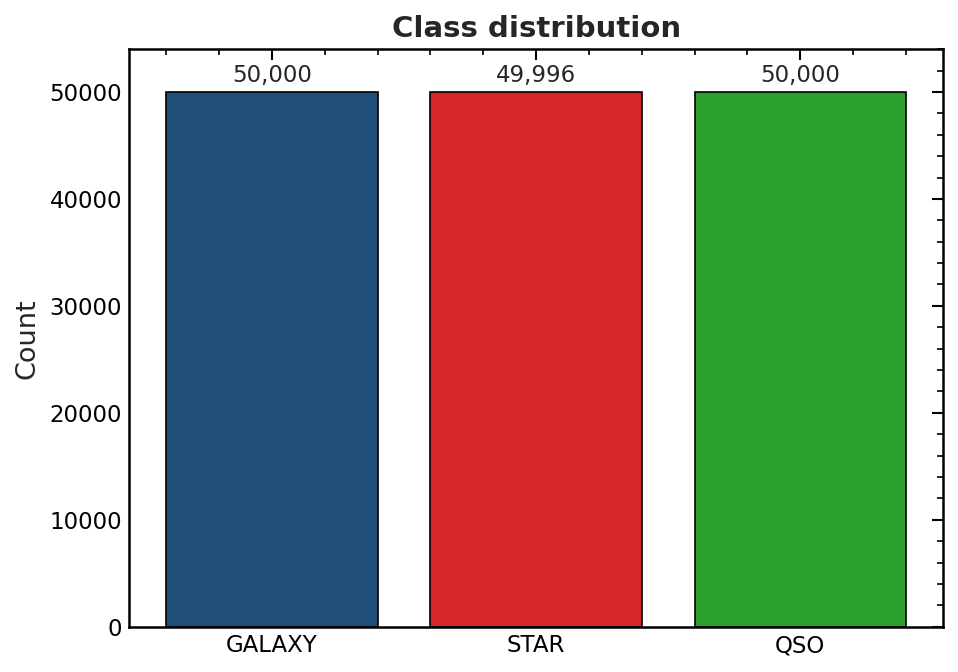

In [3]:
counts = df['class'].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c]['color'] for c in CLASSES],
              edgecolor='black', linewidth=0.8)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.01, f'{v:,}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Class distribution')
ax.set_ylim(0, max(counts.values) * 1.08)
fig.savefig(RESULTS_DIR / 'class_distribution.png')
plt.show()


## Step 3 — Redshift distribution per class (log y)

The three populations occupy distinct redshift regimes:

- **Stars** form a tight peak at $z \approx 0$ (Galactic foreground).
- **Galaxies** span roughly $z \in [0.05,\ 1.0]$.
- **Quasars** start at $z \approx 0.5$ and tail out past $z \approx 7$.

This 1-D separability is exactly what symbolic regression will exploit: there *exists* a low-complexity analytic $s(z)$ that orders the three populations along the score axis. The log y-axis is used so both the stellar locus and the long QSO tail remain visible at the same time.


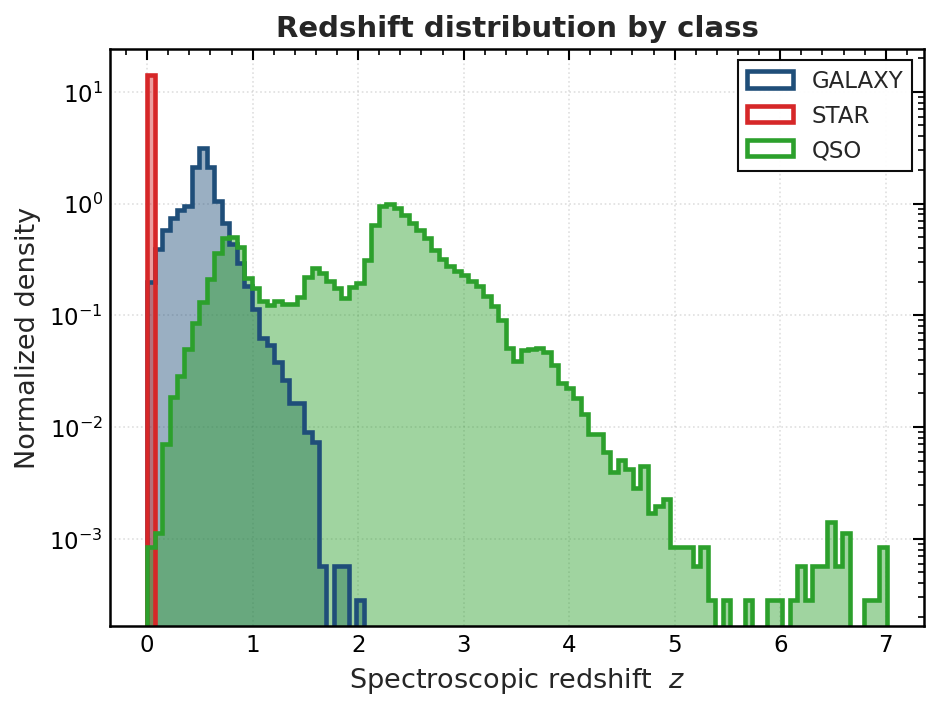

In [4]:
zmax = float(np.quantile(df['redshift'], 1.0))
bins = np.linspace(0, zmax, 100)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = df.loc[df['class'] == name, 'redshift']
    ax.hist(sub, bins=bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.set_yscale('log')
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('Normalized density')
ax.set_title('Redshift distribution by class')
ax.grid(True, alpha=0.25, linestyle=':')
ax.legend()
fig.savefig(RESULTS_DIR / 'redshift_distribution.png')
plt.show()


## Step 4 — Colour vs. redshift

A 2-D look at what a redshift-only classifier is *not* using. Stars track
a narrow horizontal locus near $z = 0$, galaxies occupy a stable colour
band across their z-range, and quasars exhibit strong colour evolution at
both ends of the z-axis. This is informative but not part of the model —
$s(z)$ stays one-dimensional.

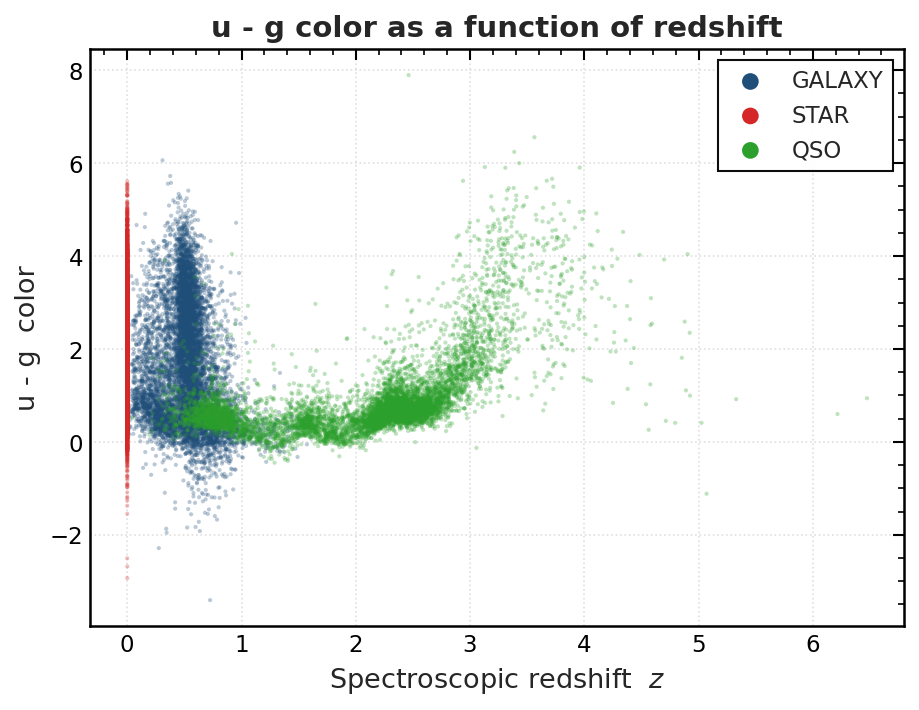

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    sub = df[df['class'] == name]
    take = min(8_000, len(sub))
    sub = sub.sample(n=take, random_state=RANDOM_STATE)
    ax.scatter(sub['redshift'], sub['u_g'], s=4, alpha=0.30,
               color=PALETTE[name]['color'], label=name, edgecolor='none')
# ax.set_xlim(-0.05, float(np.quantile(df['redshift'], 0.99)) * 1.05)
# ax.set_ylim(np.quantile(df['u_g'], 0.005), np.quantile(df['u_g'], 0.995))
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('u - g  color')
ax.set_title('u - g color as a function of redshift')
ax.grid(True, alpha=0.25, linestyle=':')
leg = ax.legend(loc='upper right', markerscale=4, framealpha=0.95)
for h in leg.legend_handles: h.set_alpha(1.0)
fig.savefig(RESULTS_DIR / 'ug_vs_z.png')
plt.show()


## Step 5 — Train / val / test split

Total dataset is partitioned into:

| Split | Fraction | Role |
| --- | --- | --- |
| TRAIN | 12.5 % | PySR sees this. Sub-split 50/50: |
|   ↳ `train_structure` | 6.25 % | PySR fits the symbolic search on this set. |
|   ↳ `train_optimize`  | 6.25 % | Constants of every Pareto candidate are refit on this set via L-BFGS. |
| VAL | 75 % | Used downstream for selection, calibration, and CV. Sub-split: |
|   ↳ `val_rerank`     | 12.5 % | Pareto re-rank (pick the equation). |
|   ↳ `val_cv`         | 62.5 %  | 5-fold cross-validation. **No train data enters CV.** |
| TEST | 12.5 % | Held-out, touched once at the end. |

All splits are stratified by class.


In [6]:
X       = df[['redshift']].values.astype(float)
dnnx    = df[['u_g', 'g_r', 'r_i', 'i_z']].values.astype(float)
y       = df['y_ord'].values.astype(int)
objlist = df['objid'].values
print('X       :', X.shape)
print('dnnx    :', dnnx.shape)
print('y       :', y.shape)
print('objlist :', objlist.shape)


X       : (149996, 1)
dnnx    : (149996, 4)
y       : (149996,)
objlist : (149996,)


In [7]:
# ---- Top-level split -------------------------------------------------------
# Stratified by class on every split.

zipX = list(zip(X, dnnx))
zipy = list(zip(y, objlist))

# 1) Carve out 12.5 % TEST.
zipX_trainval, zipX_test, zipy_trainval, zipy_test = train_test_split(
    zipX, zipy, test_size=0.125, random_state=RANDOM_STATE, stratify=y,)

# 2) From the remaining 87.5 %, peel off 12.5 % of total as TRAIN.
#    Since TRAIN is 12.5 / 87.5 = 1/7 of trainval,
#    the remaining 6/7 becomes VAL = 75 % of total.
y_trainval = np.array([t[0] for t in zipy_trainval])

zipX_train, zipX_val, zipy_train, zipy_val = train_test_split(
    zipX_trainval, zipy_trainval, test_size=6 / 7, random_state=RANDOM_STATE, stratify=y_trainval,)

# Convert back to flat numpy arrays
def _unpack(zX, zy):
    X1, dn = zip(*zX)
    yy, oo = zip(*zy)
    return (np.array(X1), np.array(dn), np.array(yy), np.array(oo),)

X_train, dnnx_train, y_train, objlist_train = _unpack(zipX_train, zipy_train)
X_val,   dnnx_val,   y_val,   objlist_val   = _unpack(zipX_val,   zipy_val)
X_test,  dnnx_test,  y_test,  objlist_test  = _unpack(zipX_test,  zipy_test)

del (zipX, zipy, zipX_trainval, zipy_trainval, zipX_train, zipy_train, zipX_val, zipy_val, zipX_test, zipy_test, y_trainval,)

# ---- TRAIN 12.5% ----------

idx_tr = np.arange(len(y_train))
X_train_struct, y_train_struct = X_train[idx_tr], y_train[idx_tr]

dnnx_train_struct = dnnx_train[idx_tr]

objlist_train_struct = objlist_train[idx_tr]

# ---- VAL sub-split: rerank / cv -------------------------------------------
# VAL is 75 % of the total dataset, split into two sub-partitions:
#   val_rerank = 1/6 of VAL = 12.5 % of total   (Pareto re-ranking)
#   val_cv     = 5/6 of VAL = 62.5 % of total   (5-fold CV threshold calibration)

idx_v = np.arange(len(y_val))

idx_rerank, idx_cv = train_test_split(
    idx_v,
    test_size=5/6,
    random_state=RANDOM_STATE,
    stratify=y_val,
)

X_val_rerank, y_val_rerank = X_val[idx_rerank], y_val[idx_rerank]
X_val_cv,     y_val_cv     = X_val[idx_cv],     y_val[idx_cv]

dnnx_val_rerank = dnnx_val[idx_rerank]
dnnx_val_cv     = dnnx_val[idx_cv]

objlist_val_rerank = objlist_val[idx_rerank]
objlist_val_cv     = objlist_val[idx_cv]

# ---- Report --------------------------------------------------------------

n_total = len(y_train) + len(y_val) + len(y_test)

print(f"Total                : {n_total:>7,}")
print(f"Train                : {len(y_train):>7,}  ({len(y_train)/n_total:.1%})")
print(f"  train_structure    : {len(y_train_struct):>7,}  ({len(y_train_struct)/n_total:.2%})")
print(f"Val                  : {len(y_val):>7,}  ({len(y_val)/n_total:.1%})")
print(f"  val_rerank         : {len(y_val_rerank):>7,}  ({len(y_val_rerank)/n_total:.2%})")
print(f"  val_cv             : {len(y_val_cv):>7,}  ({len(y_val_cv)/n_total:.2%})")
print(f"Test                 : {len(y_test):>7,}  ({len(y_test)/n_total:.1%})")

print()

for nm, yy in [
    ("train_structure", y_train_struct),
    ("val_rerank",      y_val_rerank),
    ("val_cv",          y_val_cv),
    ("test",            y_test),
]:
    cnts = pd.Series(yy).map(ORD_TO_LABEL).value_counts().to_dict()
    print(f"  {nm:18s}", cnts)
    

Total                : 149,996
Train                :  18,749  (12.5%)
  train_structure    :  18,749  (12.50%)
Val                  : 112,497  (75.0%)
  val_rerank         :  18,749  (12.50%)
  val_cv             :  93,748  (62.50%)
Test                 :  18,750  (12.5%)

  train_structure    {'GALAXY': 6250, 'QSO': 6250, 'STAR': 6249}
  val_rerank         {'GALAXY': 6250, 'QSO': 6250, 'STAR': 6249}
  val_cv             {'QSO': 31250, 'GALAXY': 31250, 'STAR': 31248}
  test               {'STAR': 6250, 'GALAXY': 6250, 'QSO': 6250}


## Step 6 — Helper functions

Three small utilities used everywhere downstream.

**`classify_scores(scores, t1, t2)`** — vectorised decision rule that assigns each row of `scores` to class **0** if $s < t_1$, class **1** if $t_1 \le s \le t_2$, and class **2** if $s > t_2$.

**`optimize_thresholds(s, y, grid=80)`** — brute-force grid search over the truncated square $[P_5,\,P_{95}]^2$ for the threshold pair that maximises the macro-F$_1$ score, subject to $t_1 < t_2$:

$$
(t_1^{\star},\, t_2^{\star}) \;=\; \underset{\substack{t_1 \,<\, t_2 \\[2pt] t_1,\, t_2 \,\in\, [P_5,\, P_{95}]}}{\arg\max} \;\; \operatorname{macro\text{-}F_1}\!\Bigl(\, y,\; \mathrm{Class}(s;\, t_1,\, t_2) \,\Bigr).
$$

**`eval_pysr_row(row, X)`** — wraps PySR's per-equation callable so it accepts either 1-D or 2-D inputs.

In [8]:
def classify_scores(scores, t1, t2):
    out = np.full_like(scores, fill_value=1, dtype=int)   # middle class
    out[scores < t1] = 0                                  # low scores
    out[scores > t2] = 2                                  # high scores
    return out

def optimize_thresholds(scores, y_true, grid=80):
    """Grid-search (t1, t2) in [P5, P95] maximizing MACRO-F1, t1 < t2."""
    lo, hi = np.percentile(scores, [5, 95])
    if hi <= lo: hi = lo + 1e-6
    cand = np.linspace(lo, hi, grid)
    best = (-1.0, lo, hi)
    for i, t1 in enumerate(cand[:-1]):
        for t2 in cand[i + 1:]:
            a = f1_score(y_true, classify_scores(scores, t1, t2), average='macro')
            if a > best[0]:
                best = (a, float(t1), float(t2))
    return best   # (best_macro_f1, t1, t2)

def eval_pysr_row(row, X):
    """Evaluate a PySR equation row on a 1-D numpy array of z (or N×1)."""
    X2 = X if X.ndim == 2 else X.reshape(-1, 1)
    out = row['lambda_format'](X2)
    return np.asarray(out, dtype=float).ravel()



# ---------- Binning + uncertainty helpers (publication-quality plots) ------

def _bin_indices(z, bins):
    """Per-row bin index in [0, n_bins-1]; rows outside bins[0]..bins[-1] get -1.
    The right edge is INCLUSIVE for the last bin (fixes the off-by-one that
    drops rows at z == bins[-1])."""
    n_bins = len(bins) - 1
    idx = np.digitize(z, bins) - 1
    idx = np.where(idx == n_bins, n_bins - 1, idx)  # z == bins[-1] -> last bin
    idx = np.where((z < bins[0]) | (z > bins[-1]), -1, idx)
    return idx


def binned_error_rate(z, errors, bins, min_count=5):
    """Return per-bin (rate, k_correct_count, n_total_count) for an error mask."""
    n_bins = len(bins) - 1
    idx    = _bin_indices(z, bins)
    rate   = np.full(n_bins, np.nan)
    n_arr  = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        m = idx == i
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            rate[i] = errors[m].mean()
    return rate, n_arr


def binned_class_recall(z, y_true, y_pred, cls_id, bins, min_count=3):
    """Per-bin (recall, k_correct, n_class_in_bin) for one class."""
    n_bins = len(bins) - 1
    idx    = _bin_indices(z, bins)
    rec    = np.full(n_bins, np.nan)
    k_arr  = np.zeros(n_bins, dtype=int)
    n_arr  = np.zeros(n_bins, dtype=int)
    mask_c = (y_true == cls_id) & (idx >= 0)
    for i in range(n_bins):
        m = (idx == i) & mask_c
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            k_arr[i] = (y_pred[m] == cls_id).sum()
            rec[i]   = k_arr[i] / n_arr[i]
    return rec, k_arr, n_arr


def wilson_ci(k, n, z=1.96):
    """Two-sided Wilson score interval for a binomial proportion.
    Robust at p == 0 or p == 1, unlike the Wald formula. Returns (lo, hi),
    NaN where n == 0."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    out_lo = np.full_like(n, np.nan, dtype=float)
    out_hi = np.full_like(n, np.nan, dtype=float)
    valid  = n > 0
    nv = n[valid]
    p  = k[valid] / nv
    denom  = 1.0 + z*z / nv
    centre = (p + z*z / (2.0 * nv)) / denom
    half   = (z / denom) * np.sqrt(p * (1 - p) / nv + z*z / (4.0 * nv * nv))
    out_lo[valid] = np.clip(centre - half, 0.0, 1.0)
    out_hi[valid] = np.clip(centre + half, 0.0, 1.0)
    return out_lo, out_hi


# Consistent per-class style for every recall plot in the notebook
CLASS_STYLE = {
    'GALAXY': {'color': '#1f4e79', 'lw': 2.6, 'order': 4},
    'STAR':   {'color': '#d62728', 'lw': 2.4, 'order': 5},
    'QSO':    {'color': '#2ca02c', 'lw': 2.4, 'order': 3},
}


def lineplot_with_band(ax, x, y, lo, hi, color, label, lw=2.4,
                       alpha_band=0.18, marker='.', ms=6):
    """Plot a curve with a shaded uncertainty band, breaking the line at NaN.
    NaNs in `y` make matplotlib leave a visual gap rather than interpolating."""
    y  = np.asarray(y, dtype=float)
    lo = np.asarray(lo, dtype=float)
    hi = np.asarray(hi, dtype=float)
    valid = np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
    if valid.any():
        ax.fill_between(x, np.clip(lo, 0, 1), np.clip(hi, 0, 1),
                        where=valid, interpolate=False,
                        color=color, alpha=alpha_band,
                        linewidth=0, zorder=3)
    ax.plot(x, np.where(valid, y, np.nan),
            color=color, linewidth=lw,
            marker=marker, markersize=ms,
            label=label, zorder=6)


# ---- Paper-style binning constants ----------------------------------------
# Full redshift range (the paper plots use the entire observed z range).
PLOT_Z_QUANTILE = 1.00
# Density histograms: many bins for smooth profile.
PLOT_N_BINS_DENSITY   = 60
# Error-rate and per-class recall curves: coarse bins matching the paper's
# marker-line style.
PLOT_N_BINS_RATE      = 15



def binned_error_rate_paper(z, errors, bins, min_count=1, zero_fill=True):
    """Per-bin error rate with paper convention (n=0 -> 0 instead of NaN)."""
    n_bins = len(bins) - 1
    idx = _bin_indices(z, bins)
    rate = np.zeros(n_bins) if zero_fill else np.full(n_bins, np.nan)
    n_arr = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        m = idx == i
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            rate[i] = errors[m].mean()
        elif not zero_fill:
            rate[i] = np.nan
    return rate, n_arr


def binned_class_recall_paper(z, y_true, y_pred, cls_id, bins,
                              min_count=1):
    """Per-bin recall with paper-style empty-bin handling:

      - **Leading empty bins** (before the class first appears) -> 0
      - **Trailing empty bins** (after the class last appears) -> 0
      - **Interior empty bins** (between two non-empty bins for this class)
        -> carry-forward from the previous non-empty bin.

    This is what the published recall-vs-redshift figures use: STAR shows
    as a step that drops at the end of its z range (trailing zeros), while
    QSO holds its value across small gaps in high-z sampling instead of
    creating spurious "V" dips."""
    n_bins = len(bins) - 1
    idx = _bin_indices(z, bins)
    k_arr = np.zeros(n_bins, dtype=int)
    n_arr = np.zeros(n_bins, dtype=int)
    rec   = np.full(n_bins, np.nan)
    mask_c = (y_true == cls_id) & (idx >= 0)
    for i in range(n_bins):
        m = (idx == i) & mask_c
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            k_arr[i] = (y_pred[m] == cls_id).sum()
            rec[i]   = k_arr[i] / n_arr[i]

    nonempty = np.where(n_arr >= min_count)[0]
    if len(nonempty) == 0:
        return np.zeros(n_bins), k_arr, n_arr

    first_idx, last_idx = int(nonempty[0]), int(nonempty[-1])
    rec[:first_idx]     = 0.0   # leading empties
    rec[last_idx + 1:]  = 0.0   # trailing empties
    last_val = 0.0
    for i in range(first_idx, last_idx + 1):  # interior carry-forward
        if np.isnan(rec[i]):
            rec[i] = last_val
        else:
            last_val = rec[i]
    return rec, k_arr, n_arr

def binned_class_recall_fold_aware(z, y_true, y_pred, cls_id, bins, min_count=1):
    """Per-bin recall for a single (fold or threshold variant). Returns
    `recall` as an array of length n_bins, with **NaN** in bins that contain
    fewer than `min_count` true samples of the target class. This lets the
    paper-style band combine multiple variants via `nanmean / nanstd`
    without empty bins biasing the result toward zero."""
    n_bins = len(bins) - 1
    idx = _bin_indices(z, bins)
    rec = np.full(n_bins, np.nan)
    n_arr = np.zeros(n_bins, dtype=int)
    mask_c = (y_true == cls_id) & (idx >= 0)
    for i in range(n_bins):
        m = (idx == i) & mask_c
        n_arr[i] = m.sum()
        if n_arr[i] >= min_count:
            rec[i] = (y_pred[m] == cls_id).mean()
    return rec, n_arr


def paper_recall_band(per_variant_recall):
    """Combine per-variant recall arrays (per-fold or per-threshold) into a
    paper-style (mean, std) summary with smart empty-bin handling:

    - **Leading** bins (before the class first appears across any variant)
      -> 0  (class doesn't exist here yet).
    - **Trailing** bins (after the class disappears across every variant)
      -> 0  (paper convention: STAR drops to 0 once stars run out).
    - **Interior** bins (an all-NaN bin between two populated bins)
      -> carry forward from the previous non-empty bin (preserves the QSO
      plateau at high z where some bins simply have no test rows).
    """
    arr = np.array(per_variant_recall, dtype=float)          # (n_var, n_bins)
    n_bins = arr.shape[1]
    with np.errstate(invalid='ignore'):
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd (arr, axis=0, ddof=1)
    all_nan = np.all(np.isnan(arr), axis=0)

    # Identify the first/last bin where at least one variant has data
    has_data = ~all_nan
    if not has_data.any():
        return np.zeros(n_bins), np.zeros(n_bins)
    first_idx = int(np.argmax(has_data))
    last_idx  = n_bins - 1 - int(np.argmax(has_data[::-1]))

    # Zero-fill leading + trailing empties; carry-forward interior empties
    last_val = 0.0
    for i in range(n_bins):
        if i < first_idx or i > last_idx:
            mean[i] = 0.0
            std[i]  = 0.0
        elif all_nan[i]:
            mean[i] = last_val
            std[i]  = 0.0
        else:
            last_val = mean[i]

    std[np.isnan(std)] = 0.0   # ddof=1 with only 1 valid variant
    return mean, std

# Per-class colors aligned with the paper's recall figure
PAPER_CLASS_STYLE = {
    'GALAXY': {'color': '#1f4eb4', 'lw': 2.6, 'order': 4},  # blue
    'STAR':   {'color': '#2ca02c', 'lw': 2.4, 'order': 5},  # green
    'QSO':    {'color': '#7e2a8e', 'lw': 2.4, 'order': 3},  # purple
}


## Step 7 — PySR symbolic search on `train_structure`

PySR's evolutionary search runs on the **TRAIN data**. That slice is `train_structure` (≈ 12.5 % of total data). The output is a Pareto frontier — for every complexity from 1 up to `COMPLEXITY_CAP`, the lowest-MSE expression found at that complexity.



In [9]:
pysr_model = PySRRegressor(
    niterations=PYSR_NITER,
    binary_operators=['+', '-', '*', '/'],
    unary_operators=['exp'],
    maxsize=COMPLEXITY_CAP,
    elementwise_loss='loss(prediction, target) = (prediction - target)^2',
    model_selection='best',
    constraints={'exp': 9},
    nested_constraints={'exp': {'exp': 0}},
    progress=True,
    random_state=RANDOM_STATE,
    deterministic=True, procs=0, multithreading=False,
    output_directory=str(RESULTS_DIR / 'pysr_search'),
    verbosity=1,
)
pysr_model.fit(X_train_struct, y_train_struct.astype(float))

equations = pysr_model.equations_.copy()

required_cols = {'complexity', 'loss', 'equation', 'lambda_format'}
missing = required_cols - set(equations.columns)
assert not missing, (
    f'Unexpected PySR equations_ schema: missing columns {missing}. '
    f'Got columns: {list(equations.columns)}. '
    f'Check your PySR version (`pip show pysr`).'
)
equations = equations[equations['complexity'] <= COMPLEXITY_CAP].reset_index(drop=True)

print(f'Pareto frontier rows (C ≤ {COMPLEXITY_CAP}): {len(equations)}')
equations[['complexity', 'loss', 'equation']]


/home/srinadb/anaconda3/envs/srinadh_astro/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/srinadb/anaconda3/envs/srinadh_astro/lib/python3.10/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
Compiling Julia backend...
/home/srinadb/anaconda3/envs/srinadh_astro/lib/python3.10/site-packages/pysr/sr.py:2858: UserWarning: The `multithreading: bool` parameter has been deprecated in favor of `parallelism: Literal['multithreading'


Expressions evaluated per second: 1.510e+04
Progress: 84 / 15500 total iterations (0.542%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.666e-01  0.000e+00  y = 1.0003
3           2.952e-01  4.072e-01  y = x₀ * 0.88021
5           1.968e-01  2.029e-01  y = (x₀ * 0.67824) + 0.41313
8           6.649e-02  3.617e-01  y = (x₀ * 2.5435) / exp(x₀ * 0.46436)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.


[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form.
[ Info: Started!
IOStream.flush timed out
IOStream.flush timed out



Expressions evaluated per second: 1.260e+04
Progress: 150 / 15500 total iterations (0.968%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.666e-01  0.000e+00  y = 1.0003
3           2.952e-01  4.072e-01  y = x₀ * 0.88021
5           1.968e-01  2.029e-01  y = (x₀ * 0.67824) + 0.41313
6           1.791e-01  9.401e-02  y = exp(-0.0085677 / x₀) / 0.73991
7           5.853e-02  1.119e+00  y = 2.4451 / ((x₀ + 0.56199) / x₀)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.100e+04
Progress: 197 / 15500 total iterations (1.271%)
════════════════════

IOStream.flush timed out
IOStream.flush timed out


...


Expressions evaluated per second: 8.130e+03
Progress: 2359 / 15500 total iterations (15.219%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.206e-01  0.000e+00  y = x₀
3           2.952e-01  4.127e-02  y = x₀ * 0.88021
5           1.968e-01  2.029e-01  y = (x₀ * 0.67824) + 0.41313
6           7.064e-02  1.024e+00  y = exp((-0.31899 / x₀) + 0.79909)
7           5.830e-02  1.920e-01  y = 2.4607 - (1.4239 / (x₀ + 0.58504))
8           5.806e-02  4.117e-03  y = (-2.1147 / (exp(x₀) + x₀)) + 2.1384
10          5.803e-02  2.265e-04  y = (-2.1806 / ((x₀ + 0.027712) + exp(x₀))) + 2.1487
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Pr

IOStream.flush timed out
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 5.520e+03
Progress: 15445 / 15500 total iterations (99.645%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.206e-01  0.000e+00  y = x₀
3           2.952e-01  4.127e-02  y = x₀ * 0.88021
5           1.968e-01  2.029e-01  y = (x₀ * 0.67824) + 0.41313
6           7.064e-02  1.024e+00  y = exp((-0.31896 / x₀) + 0.79908)
7           5.830e-02  1.920e-01  y = 2.455 - (1.41 / (x₀ + 0.58053))
8           5.806e-02  4.086e-03  y = (-2.1147 / (exp(x₀) + x₀)) + 2.1384
10          5.803e-02  2.266e-04  y = (-2.1806 / ((x₀ + 0.027717) + exp(x₀))) + 2.1487
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Pres

,complexity,loss,equation
0,1,0.320639,x0
1,3,0.295236,x0 * 0.88020885
2,5,0.196770,(x0 * 0.6782437) + 0.41312915
3,6,0.070639,exp((-0.31895587 / x0) + 0.7990808)
4,7,0.058299,2.4550219 - (1.4099945 / (x0 + 0.58053213))
5,8,0.058061,(-2.1147215 / (exp(x0) + x0)) + 2.1383712
6,10,0.058035,(-2.1805785 / ((x0 + 0.027716832) + exp(x0))) ...


  - Ex2_SR_SGQ/pysr_search/20260827_202711_8XNLS1/hall_of_fame.csv


## Step 8 — Pareto re-ranking on `val_rerank` via threshold-region likelihood AIC / BIC

For each PySR Pareto candidate, we evaluate its symbolic score $s(x)$ on the held-out `val_rerank` set. We grid-search two thresholds $(t_1, t_2)$ to define the 3-class symbolic classifier:

$$
s_i < t_1 \;\Rightarrow\; \hat{y}_i = 0,
$$

$$
t_1 \le s_i < t_2 \;\Rightarrow\; \hat{y}_i = 1,
$$

$$
s_i \ge t_2 \;\Rightarrow\; \hat{y}_i = 2.
$$

For the star–galaxy–QSO problem, the labels correspond to the three target classes:

$$
0 \rightarrow \text{STAR}, \qquad
1 \rightarrow \text{GALAXY}, \qquad
2 \rightarrow \text{QSO}.
$$

The same threshold pair $(t_1,t_2)$ is used to report validation accuracy and macro-$F_1$. However, the final model-selection score is not based directly on $F_1$. Instead, we use a likelihood defined from the thresholded score regions.

The two thresholds divide the symbolic score axis into three regions:

$$
r_i =
\begin{cases}
0, & s_i < t_1, \\
1, & t_1 \le s_i < t_2, \\
2, & s_i \ge t_2.
\end{cases}
$$

For each region, we estimate the class probabilities from the held-out `val_rerank` data:

$$
P(y=c \mid r)
=
\frac{N_{r,c} + \alpha}{N_r + \alpha K},
$$

where

- $r \in \{0,1,2\}$ is the threshold region,
- $c \in \{0,1,2\}$ is the class label,
- $N_{r,c}$ is the number of validation samples in region $r$ with class $c$,
- $N_r$ is the total number of validation samples in region $r$,
- $K=3$ is the number of classes,
- $\alpha$ is the Laplace smoothing constant.

The likelihood of the observed labels is

$$
L
=
\prod_{i=1}^{n}
P(y_i \mid r_i),
$$

and the log-likelihood is

$$
\log L
=
\sum_{i=1}^{n}
\log P(y_i \mid r_i).
$$

The information criteria are computed as

$$
\text{AIC}(s)
=
-2\log L
+
2k,
$$

$$
\text{BIC}(s)
=
-2\log L
+
k\log n.
$$

The total complexity used in the information criterion is

$$
k = C + 2 + 6,
$$

where

- $C$ is the PySR structural complexity of the equation,
- $2$ accounts for the learned thresholds $(t_1,t_2)$,
- $6$ accounts for the region-wise class probability parameters.

The probability-parameter count is

$$
R(K-1) = 3(3-1) = 6,
$$

where $R=3$ is the number of threshold regions and $K=3$ is the number of classes. Each region has a categorical distribution over three classes, but because the probabilities in each region must sum to one, each region contributes only $K-1=2$ free probability parameters.

Therefore,

$$
k = C + 8.
$$

**Lower is better.** The likelihood term rewards symbolic equations whose threshold regions are class-pure on the held-out reranking set. The complexity penalty discourages unnecessarily complicated symbolic expressions. BIC is more parsimony-leaning than AIC because it charges each additional complexity unit by $\log n$ rather than by $2$.

The equation with the smallest BIC is selected for downstream calibration using 5-fold CV on `val_cv`. Companion columns `delta_aic` and `delta_bic` record the gap from the minimum AIC and BIC values, respectively.

In this setup, the likelihood is aligned with the actual symbolic threshold classifier. The reported metrics `val_rerank_acc` and `val_rerank_f1` are diagnostic summaries of the same threshold rule, while AIC/BIC use the corresponding region-wise categorical likelihood.

**Note:** This is more appropriate for a symbolic 3-class threshold classifier than multinomial logistic calibration if the final model is intended to be a hard threshold rule. However, PySR complexity is still a structural node count rather than a literal count of free statistical parameters. Therefore, the resulting AIC/BIC values should be interpreted as likelihood-based symbolic model-selection scores, with the complexity penalty approximated by the PySR expression complexity plus the threshold and region-probability parameters.

In [10]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder


# -----------------------------
# Step 8 — Pareto re-ranking using threshold-region categorical AIC / BIC
# for 3-class star / galaxy / QSO classification
# -----------------------------

n_oos = int(len(y_val_rerank))
ln_n  = math.log(n_oos)

eps = 1e-12
alpha_smooth = 1.0   # Laplace smoothing

label_encoder = LabelEncoder()
y_rr_enc = label_encoder.fit_transform(y_val_rerank)

class_labels = label_encoder.classes_
n_classes = len(class_labels)

if n_classes != 3:
    raise ValueError(
        f"Expected 3 classes, but found {n_classes}: {class_labels}"
    )

n_regions = 3

rerank_rows = []

for i, row in equations.iterrows():

    s_rr = eval_pysr_row(row, X_val_rerank)

    if not np.isfinite(s_rr).all():
        continue

    s_rr = np.asarray(s_rr, dtype=float).ravel()

    # -------------------------------------------------------
    # Optimize two thresholds for the actual classifier
    # -------------------------------------------------------
    _, t1_rr, t2_rr = optimize_thresholds(s_rr, y_val_rerank)

    if t1_rr > t2_rr:
        t1_rr, t2_rr = t2_rr, t1_rr

    yp_rr = classify_scores(s_rr, t1_rr, t2_rr)

    acc_rr = accuracy_score(y_val_rerank, yp_rr)
    f1_rr  = f1_score(y_val_rerank, yp_rr, average="macro")

    # -------------------------------------------------------
    # Convert score into three threshold regions:
    #
    # region 0: s < t1
    # region 1: t1 <= s < t2
    # region 2: s >= t2
    #
    # Then estimate P(class | region).
    # This likelihood matches the threshold classifier.
    # -------------------------------------------------------
    region_rr = np.digitize(s_rr, bins=[t1_rr, t2_rr], right=False)

    # Counts: rows = threshold regions, columns = true classes
    counts = np.zeros((n_regions, n_classes), dtype=float)

    for r, y in zip(region_rr, y_rr_enc):
        counts[r, y] += 1.0

    # Laplace-smoothed categorical probabilities
    probs_region_class = counts + alpha_smooth
    probs_region_class /= probs_region_class.sum(axis=1, keepdims=True)

    # Probability assigned to the true class of each sample
    p_true = probs_region_class[region_rr, y_rr_enc]
    p_true = np.clip(p_true, eps, 1.0)

    # Categorical log-likelihood
    log_likelihood = np.sum(np.log(p_true))
    neg2_log_likelihood = -2.0 * log_likelihood

    # -------------------------------------------------------
    # Complexity / parameter count
    #
    # C = PySR expression complexity
    # 2 = thresholds t1 and t2
    # n_regions * (n_classes - 1) = categorical probabilities per region
    #
    # For 3 regions and 3 classes:
    # probability parameters = 3 * (3 - 1) = 6
    #
    # total k = C + 2 + 6
    # -------------------------------------------------------
    k_struct = int(row["complexity"])
    k_thr    = 2
    k_prob   = n_regions * (n_classes - 1)
    k_total  = k_struct + k_thr + k_prob

    aic = neg2_log_likelihood + 2.0 * k_total
    bic = neg2_log_likelihood + k_total * ln_n

    score = bic

    rerank_rows.append({
        "idx_eq":              int(i),
        "complexity":          int(k_struct),
        "k_thresholds":        int(k_thr),
        "k_probabilities":     int(k_prob),
        "k_total_for_ic":      int(k_total),

        "pysr_loss":           float(row["loss"]),

        "val_rerank_acc":      float(acc_rr),
        "val_rerank_f1":       float(f1_rr),

        "log_likelihood":      float(log_likelihood),
        "neg2_log_likelihood": float(neg2_log_likelihood),

        "aic":                 float(aic),
        "bic":                 float(bic),
        "selection_score":     float(score),

        "t1_probe":            float(t1_rr),
        "t2_probe":            float(t2_rr),

        "classes":             list(class_labels),
        "region_class_counts": counts.tolist(),
        "region_class_probs":  probs_region_class.tolist(),

        "equation":            str(row["equation"]),
    })


pareto_df = pd.DataFrame(rerank_rows).sort_values(
    "selection_score",
    ascending=True
).reset_index(drop=True)

pareto_df["delta_aic"] = pareto_df["aic"] - pareto_df["aic"].min()
pareto_df["delta_bic"] = pareto_df["bic"] - pareto_df["bic"].min()

pareto_df.to_csv(RESULTS_DIR / "pareto_frontier.csv", index=False)

pareto_df

,idx_eq,complexity,k_thresholds,k_probabilities,k_total_for_ic,pysr_loss,val_rerank_acc,val_rerank_f1,log_likelihood,neg2_log_likelihood,...,bic,selection_score,t1_probe,t2_probe,classes,region_class_counts,region_class_probs,equation,delta_aic,delta_bic
0,4,7,2,6,15,0.058299,0.938823,0.938764,-3939.675319,7879.350638,...,8026.934073,8026.934073,0.051827,1.425770,"[0, 1, 2]","[[6249.0, 27.0, 0.0], [0.0, 5723.0, 620.0], [0...","[[0.9953814301640389, 0.004459308807134894, 0....",2.4550219 - (1.4099945 / (x0 + 0.58053213)),0.564815,0.000000
1,6,10,2,6,18,0.058035,0.938930,0.938872,-3936.392911,7872.785822,...,8049.885945,8049.885945,0.052501,1.424514,"[0, 1, 2]","[[6249.0, 27.0, 0.0], [0.0, 5715.0, 610.0], [0...","[[0.9953814301640389, 0.004459308807134894, 0....",(-2.1805785 / ((x0 + 0.027716832) + exp(x0))) ...,0.000000,22.951872
2,5,8,2,6,16,0.058061,0.938237,0.938169,-3951.147543,7902.295086,...,8059.717417,8059.717417,0.049170,1.443975,"[0, 1, 2]","[[6249.0, 27.0, 0.0], [0.0, 5776.0, 684.0], [0...","[[0.9953814301640389, 0.004459308807134894, 0....",(-2.1147215 / (exp(x0) + x0)) + 2.1383712,25.509264,32.783344
3,0,1,2,6,9,0.320639,0.937597,0.937504,-4008.090024,8016.180048,...,8104.730109,8104.730109,0.035325,0.811647,"[0, 1, 2]","[[6249.0, 39.0, 0.0], [0.0, 5778.0, 698.0], [0...","[[0.9934827531394055, 0.006358289620092195, 0....",x0,125.394226,77.796036
4,1,3,2,6,11,0.295236,0.937597,0.937504,-4008.090024,8016.180048,...,8124.407901,8124.407901,0.031094,0.714419,"[0, 1, 2]","[[6249.0, 39.0, 0.0], [0.0, 5778.0, 698.0], [0...","[[0.9934827531394055, 0.006358289620092195, 0....",x0 * 0.88020885,129.394226,97.473827
5,2,5,2,6,13,0.196770,0.937597,0.937504,-4008.090024,8016.180048,...,8144.085692,8144.085692,0.437088,0.963623,"[0, 1, 2]","[[6249.0, 39.0, 0.0], [0.0, 5778.0, 698.0], [0...","[[0.9934827531394055, 0.006358289620092195, 0....",(x0 * 0.6782437) + 0.41312915,133.394226,117.151619
6,3,6,2,6,14,0.070639,0.935517,0.935316,-4239.761380,8479.522761,...,8617.267300,8617.267300,0.025103,1.481058,"[0, 1, 2]","[[6249.0, 91.0, 1.0], [0.0, 5646.0, 604.0], [0...","[[0.9851828499369483, 0.014501891551071878, 0....",exp((-0.31895587 / x0) + 0.7990808),598.736938,590.333227


## Step 9 — Lock in the winner

The top row of the re-ranked frontier gives us the equation. We pull its callable out of `refined_df` (indexed via `idx_refined`). Thresholds are **not** frozen here — they're calibrated next.


In [11]:
best = pareto_df.iloc[0]
best_idx_eq = int(best['idx_eq'])
best_equation_str = best['equation']
best_eq_row = equations.iloc[best_idx_eq]

def score_fn(X):
    return eval_pysr_row(best_eq_row, np.asarray(X))

print(f'Selected equation     : s(z) = {best_equation_str}')
print(f'Complexity (k)        : {int(best["complexity"])}')
print(f'val_rerank macro-F1   : {best["val_rerank_f1"]:.4f}')
print(f'val_rerank accuracy   : {best["val_rerank_acc"]:.4f}   (diagnostic)')
print(f'Selection score (BIC) : {best["selection_score"]:.4f}   (lower is better)')
print(f'(thresholds will be taken as the CV-fold mean in Step 11)')


Selected equation     : s(z) = 2.4550219 - (1.4099945 / (x0 + 0.58053213))
Complexity (k)        : 7
val_rerank macro-F1   : 0.9388
val_rerank accuracy   : 0.9388   (diagnostic)
Selection score (BIC) : 8026.9341   (lower is better)
(thresholds will be taken as the CV-fold mean in Step 11)


## Step 10 — Pareto frontier

Loss vs. complexity, with the selected expression highlighted as a red star. The diminishing-returns shape — steep drop early, plateau later — is what a well-formed frontier looks like.


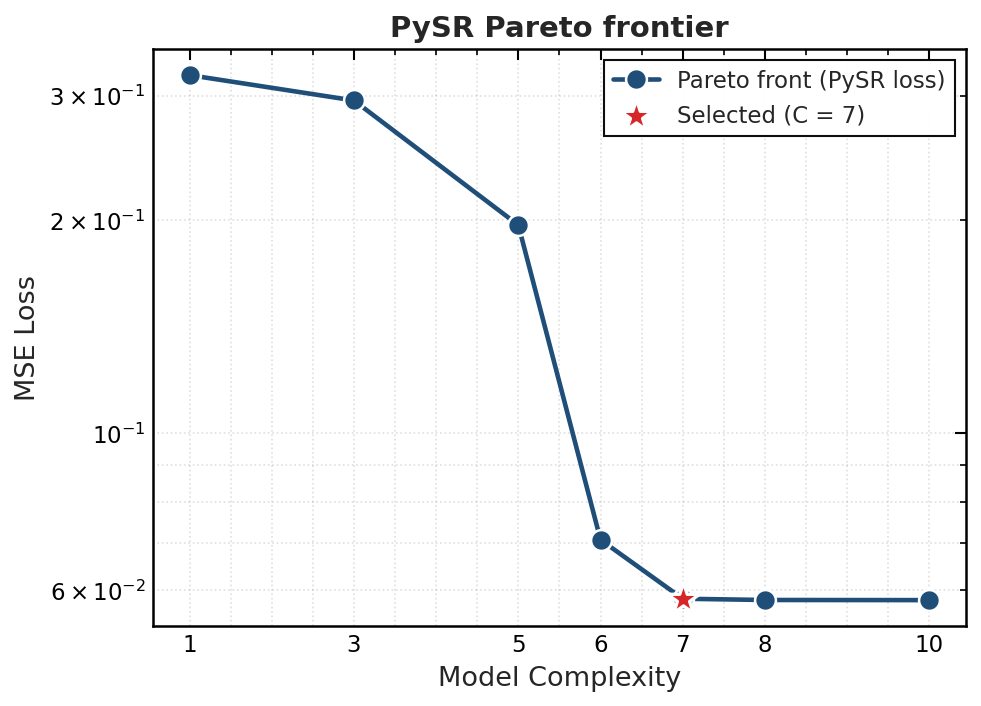

In [12]:
selected_complexity = int(best['complexity'])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
plot_df = pareto_df.sort_values('complexity')
ax.plot(plot_df['complexity'], plot_df['pysr_loss'],
        marker='o', markersize=10, linewidth=2.2,
        color='#1f4e79', label='Pareto front (PySR loss)',
        markerfacecolor='#1f4e79', markeredgecolor='white',
        markeredgewidth=1.2, zorder=2)
sel_row = plot_df[plot_df['complexity'] == selected_complexity].iloc[0]
ax.scatter([sel_row['complexity']], [sel_row['pysr_loss']],
           s=260, color='#d62728', marker='*',
           edgecolor='white', linewidth=1.6, zorder=5,
           label=f'Selected (C = {selected_complexity})')
ax.set_xlabel('Model Complexity')
ax.set_ylabel('MSE Loss')
ax.set_yscale('log')
ax.set_xticks(sorted(plot_df['complexity'].unique()))
ax.set_title('PySR Pareto frontier')
ax.grid(True, alpha=0.25, linestyle=':', which='both')
ax.legend(loc='upper right')
fig.savefig(RESULTS_DIR / 'pareto_frontier.png')
plt.show()


In [13]:
# selected_complexity = int(best['complexity'])

# fig, ax1 = plt.subplots(figsize=FIGSIZE_SINGLE)

# plot_df = pareto_df.sort_values('complexity').copy()

# # -----------------------------
# # Left axis: PySR loss
# # -----------------------------
# ax1.plot(
#     plot_df['complexity'],
#     plot_df['pysr_loss'],
#     marker='o',
#     markersize=10,
#     linewidth=2.2,
#     color='#1f4e79',
#     label='PySR loss',
#     markerfacecolor='#1f4e79',
#     markeredgecolor='white',
#     markeredgewidth=1.2,
#     zorder=2
# )

# sel_row = plot_df[plot_df['complexity'] == selected_complexity].iloc[0]

# ax1.scatter(
#     [sel_row['complexity']],
#     [sel_row['pysr_loss']],
#     s=260,
#     color='#d62728',
#     marker='*',
#     edgecolor='white',
#     linewidth=1.6,
#     zorder=5,
#     label=f'Selected loss (C = {selected_complexity})'
# )

# ax1.set_xlabel('Model Complexity')
# ax1.set_ylabel('MSE Loss')
# ax1.set_yscale('log')
# ax1.set_xticks(sorted(plot_df['complexity'].unique()))
# ax1.grid(True, alpha=0.25, linestyle=':', which='both')


# # -----------------------------
# # Right axis: validation accuracy
# # -----------------------------
# ax2 = ax1.twinx()

# ax2.plot(
#     plot_df['complexity'],
#     plot_df['val_rerank_acc'],
#     marker='s',
#     markersize=8,
#     linewidth=2.0,
#     linestyle='--',
#     color='#2ca02c',
#     label='Validation accuracy',
#     markerfacecolor='#2ca02c',
#     markeredgecolor='white',
#     markeredgewidth=1.0,
#     zorder=3
# )

# ax2.scatter(
#     [sel_row['complexity']],
#     [sel_row['val_rerank_acc']],
#     s=180,
#     color='#ff7f0e',
#     marker='D',
#     edgecolor='white',
#     linewidth=1.4,
#     zorder=6,
#     label=f'Selected accuracy = {sel_row["val_rerank_acc"]:.3f}'
# )

# ax2.set_ylabel('Validation Accuracy')
# ax2.set_ylim(0.0, 1.02)


# # -----------------------------
# # Combined legend
# # -----------------------------
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc='lower left',
#     frameon=True
# )

# ax1.set_title('PySR Pareto frontier')

# fig.tight_layout()
# fig.savefig(RESULTS_DIR / 'pareto_frontier_loss_accuracy.png', dpi=300, bbox_inches='tight')
# plt.show()


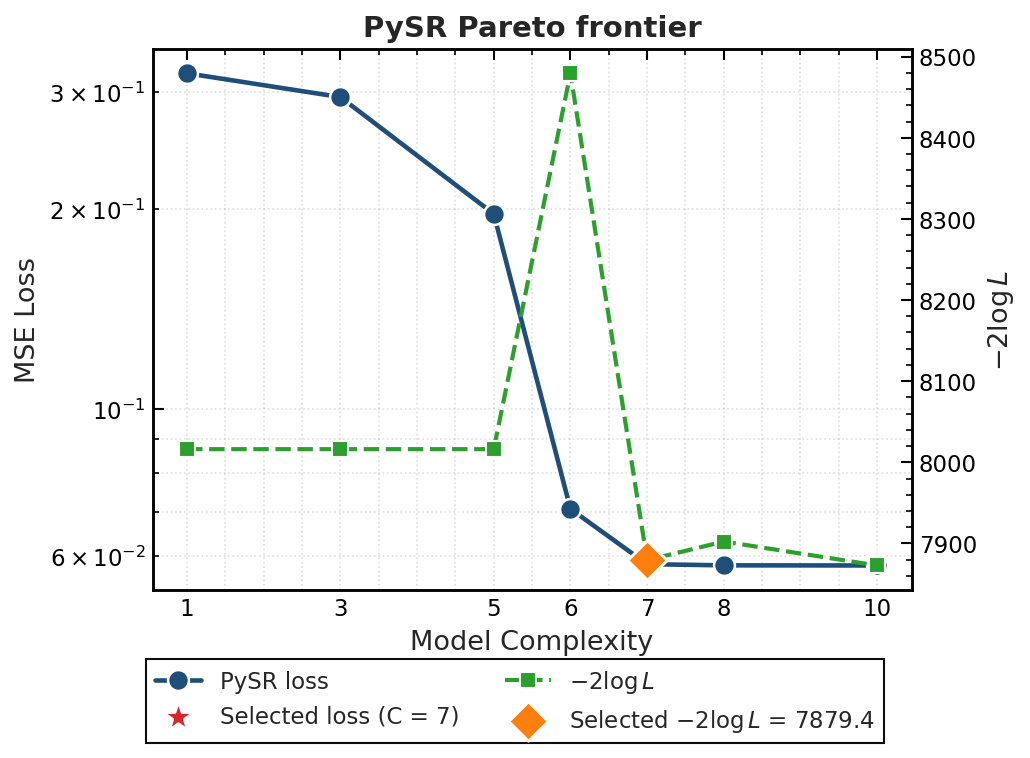

In [14]:

selected_complexity = int(best['complexity'])

fig, ax1 = plt.subplots(figsize=FIGSIZE_SINGLE)

plot_df = pareto_df.sort_values('complexity').copy()

# -----------------------------
# Left axis: PySR loss
# -----------------------------
ax1.plot(
    plot_df['complexity'],
    plot_df['pysr_loss'],
    marker='o',
    markersize=10,
    linewidth=2.2,
    color='#1f4e79',
    label='PySR loss',
    markerfacecolor='#1f4e79',
    markeredgecolor='white',
    markeredgewidth=1.2,
    zorder=2
)

# Safer selection: use idx_eq if available, otherwise use complexity
if 'idx_eq' in best.index and 'idx_eq' in plot_df.columns:
    sel_row = plot_df[plot_df['idx_eq'] == int(best['idx_eq'])].iloc[0]
else:
    sel_row = plot_df[plot_df['complexity'] == selected_complexity].iloc[0]

ax1.scatter(
    [sel_row['complexity']],
    [sel_row['pysr_loss']],
    s=260,
    color='#d62728',
    marker='*',
    edgecolor='white',
    linewidth=1.6,
    zorder=5,
    label=f'Selected loss (C = {selected_complexity})'
)

ax1.set_xlabel('Model Complexity')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')
ax1.set_xticks(sorted(plot_df['complexity'].unique()))
ax1.grid(True, alpha=0.25, linestyle=':', which='both')


# -----------------------------
# Right axis: likelihood score
# -----------------------------
ax2 = ax1.twinx()

ax2.plot(
    plot_df['complexity'],
    plot_df['neg2_log_likelihood'],
    marker='s',
    markersize=8,
    linewidth=2.0,
    linestyle='--',
    color='#2ca02c',
    label=r'$-2\log L$',
    markerfacecolor='#2ca02c',
    markeredgecolor='white',
    markeredgewidth=1.0,
    zorder=3
)

ax2.scatter(
    [sel_row['complexity']],
    [sel_row['neg2_log_likelihood']],
    s=180,
    color='#ff7f0e',
    marker='D',
    edgecolor='white',
    linewidth=1.4,
    zorder=6,
    label=rf'Selected $-2\log L$ = {sel_row["neg2_log_likelihood"]:.1f}'
)

ax2.set_ylabel(r'$-2\log L$')
ax2.grid(False)


# -----------------------------
# Combined legend outside plot
# -----------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=True
)

ax1.set_title('PySR Pareto frontier')

# Leave space at bottom for legend
fig.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    RESULTS_DIR / 'pareto_frontier_loss_likelihood.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## Step 11 — 5-fold stratified cross-validation on `val_cv`

The CV pool is **`val_cv` only** (37.5 % of total). Train data is deliberately excluded — that's the data PySR fitted on, and including it would inflate CV metrics.

For each fold, the equation is frozen and `(t₁, t₂)` is re-calibrated on the fold's training portion. This gives us a stability band around the final calibrated thresholds.


In [15]:
X_pool = X_val_cv
y_pool = y_val_cv
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_records, fold_cms, fold_predictions = [], [], []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_pool, y_pool), start=1):
    s_tr = score_fn(X_pool[tr_idx].ravel())
    s_te = score_fn(X_pool[te_idx].ravel())
    _, t1_fold, t2_fold = optimize_thresholds(s_tr, y_pool[tr_idx], grid=40)
    yp = classify_scores(s_te, t1_fold, t2_fold)

    cm = confusion_matrix(y_pool[te_idx], yp, labels=LABEL_ORDER, normalize='true')
    fold_cms.append(cm)
    fold_records.append({
        'fold':      fold,
        't1':        float(t1_fold),
        't2':        float(t2_fold),
        'accuracy':  accuracy_score(y_pool[te_idx], yp),
        'precision': precision_score(y_pool[te_idx], yp, average='macro', zero_division=0),
        'recall':    recall_score(y_pool[te_idx], yp, average='macro', zero_division=0),
        'f1':        f1_score(y_pool[te_idx], yp, average='macro'),
    })
    fold_predictions.append((X_pool[te_idx].ravel(), y_pool[te_idx], yp))

cv_df = pd.DataFrame(fold_records)
cv_summary = cv_df.drop(columns=['fold']).agg(['mean', 'std'])
cv_df.to_csv(RESULTS_DIR / 'cv_folds.csv', index=False)
cv_summary.to_csv(RESULTS_DIR / 'cv_summary.csv')

print('Per-fold:'); print(cv_df.to_string(index=False))
print('\n5-fold CV summary (mean ± std):')
for m in ['accuracy', 'precision', 'recall', 'f1']:
    print(f'  {m:10s}: {cv_df[m].mean():.4f} ± {cv_df[m].std():.4f}')
print(f'  t1        : {cv_df["t1"].mean():.4f} ± {cv_df["t1"].std():.4f}')
print(f'  t2        : {cv_df["t2"].mean():.4f} ± {cv_df["t2"].std():.4f}')


Per-fold:
 fold       t1       t2  accuracy  precision   recall       f1
    1 0.077977 1.419215  0.934187   0.934114 0.934187 0.934132
    2 0.077960 1.418668  0.937813   0.937718 0.937813 0.937759
    3 0.077954 1.418576  0.935413   0.935316 0.935413 0.935352
    4 0.077962 1.418805  0.934557   0.934485 0.934560 0.934505
    5 0.077968 1.418886  0.934610   0.934545 0.934613 0.934554

5-fold CV summary (mean ± std):
  accuracy  : 0.9353 ± 0.0015
  precision : 0.9352 ± 0.0015
  recall    : 0.9353 ± 0.0015
  f1        : 0.9353 ± 0.0015
  t1        : 0.0780 ± 0.0000
  t2        : 1.4188 ± 0.0002


## Step 12a — Frozen evaluation on TEST

Frozen equation + calibrated `(t₁, t₂)` applied to TEST. The test set has been untouched by every previous decision.


In [16]:
t1_mean = float(cv_df["t1"].mean())
t2_mean = float(cv_df["t2"].mean())


In [17]:
z_test = X_test.ravel()
s_test = score_fn(z_test)
y_pred = classify_scores(s_test, t1_mean, t2_mean)

acc_t  = accuracy_score(y_test, y_pred)
prec_t = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_t  = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_t   = f1_score(y_test, y_pred, average='macro')

pc_p, pc_r, pc_f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=LABEL_ORDER, zero_division=0)
cm_test_raw  = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
cm_test_norm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER, normalize='true')

print(f'TEST  n = {len(y_test):,}   (CV-mean thresholds: t1={t1_mean:.4f}, t2={t2_mean:.4f})')
print(f'  Accuracy          : {acc_t:.4f}')
print(f'  Precision (macro) : {prec_t:.4f}')
print(f'  Recall    (macro) : {rec_t:.4f}')
print(f'  F1        (macro) : {f1_t:.4f}')
print()
print(classification_report(y_test, y_pred, labels=LABEL_ORDER,
                            target_names=CLASSES, digits=4, zero_division=0))


TEST  n = 18,750   (CV-mean thresholds: t1=0.0780, t2=1.4188)
  Accuracy          : 0.9366
  Precision (macro) : 0.9366
  Recall    (macro) : 0.9366
  F1        (macro) : 0.9366

              precision    recall  f1-score   support

      GALAXY     0.9014    0.9094    0.9054      6250
        STAR     0.9960    1.0000    0.9980      6250
         QSO     0.9123    0.9005    0.9064      6250

    accuracy                         0.9366     18750
   macro avg     0.9366    0.9366    0.9366     18750
weighted avg     0.9366    0.9366    0.9366     18750



### Step 12b — TEST metrics across all CV-fold thresholds

The thresholds `(t1_mean, t2_mean)` used above are the mean of the 5 CV folds. Below we re-evaluate the **frozen equation on TEST** using *each* fold's own thresholds, so we can report the mean ± std of every classification metric. This quantifies how sensitive the final test-set numbers are to small perturbations in `(t1, t2)`.


In [18]:
# Re-evaluate TEST using each CV fold's (t1, t2) and tabulate mean +/- std
_test_rows = []
for _, _r in cv_df.iterrows():
    _yp = classify_scores(s_test, float(_r['t1']), float(_r['t2']))
    _test_rows.append({
        'fold':      int(_r['fold']),
        't1':        float(_r['t1']),
        't2':        float(_r['t2']),
        'accuracy':  accuracy_score(y_test, _yp),
        'precision': precision_score(y_test, _yp, average='macro', zero_division=0),
        'recall':    recall_score(y_test, _yp, average='macro', zero_division=0),
        'f1':        f1_score(y_test, _yp, average='macro'),
    })
test_fold_metrics_df = pd.DataFrame(_test_rows)

print('TEST metrics across {} fold (t1,t2) pairs:'.format(len(test_fold_metrics_df)))
print(test_fold_metrics_df.to_string(index=False, float_format='%.4f'))
print()
print('Summary (mean +/- std, ddof=1):')
test_summary_df = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1'],
    'mean':   [test_fold_metrics_df[m].mean() for m in ['accuracy','precision','recall','f1']],
    'std':    [test_fold_metrics_df[m].std(ddof=1) for m in ['accuracy','precision','recall','f1']],
})
print(test_summary_df.to_string(index=False, float_format='%.4f'))

test_fold_metrics_df.to_csv(RESULTS_DIR / 'test_metrics_per_fold.csv', index=False)
test_summary_df.to_csv(RESULTS_DIR / 'test_metrics_summary.csv', index=False)


TEST metrics across 5 fold (t1,t2) pairs:
 fold     t1     t2  accuracy  precision  recall     f1
    1 0.0780 1.4192    0.9366     0.9365  0.9366 0.9365
    2 0.0780 1.4187    0.9367     0.9366  0.9367 0.9366
    3 0.0780 1.4186    0.9367     0.9366  0.9367 0.9366
    4 0.0780 1.4188    0.9367     0.9366  0.9367 0.9366
    5 0.0780 1.4189    0.9366     0.9366  0.9366 0.9366

Summary (mean +/- std, ddof=1):
   metric   mean    std
 accuracy 0.9367 0.0000
precision 0.9366 0.0000
   recall 0.9367 0.0000
       f1 0.9366 0.0000


## Step 12c — Confusion matrices: CV (val_cv mean) vs. TEST

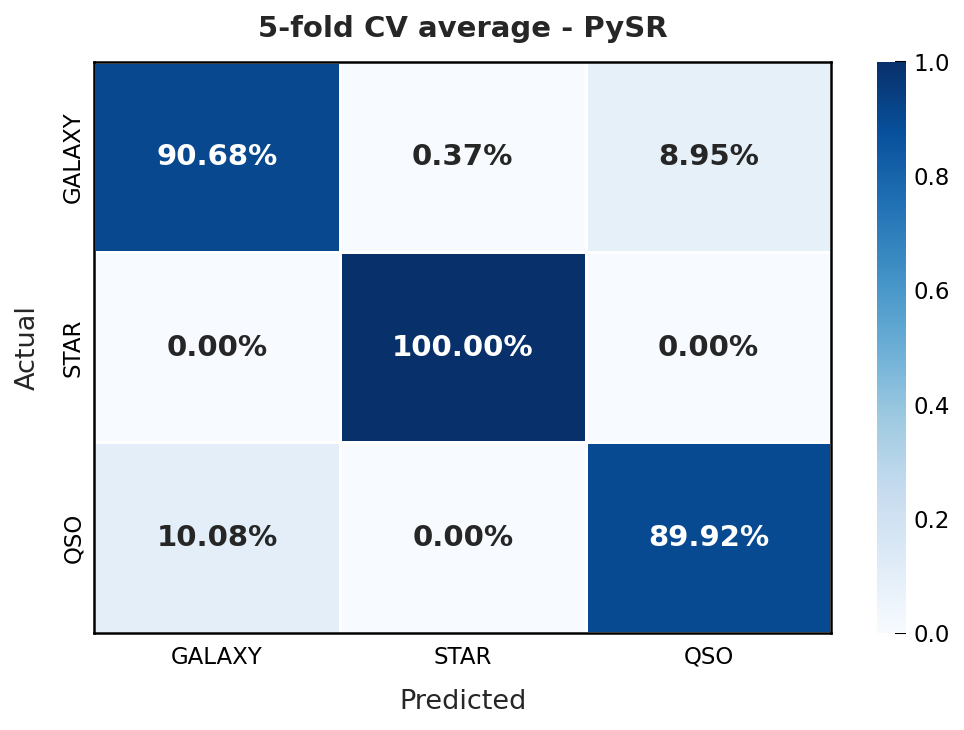

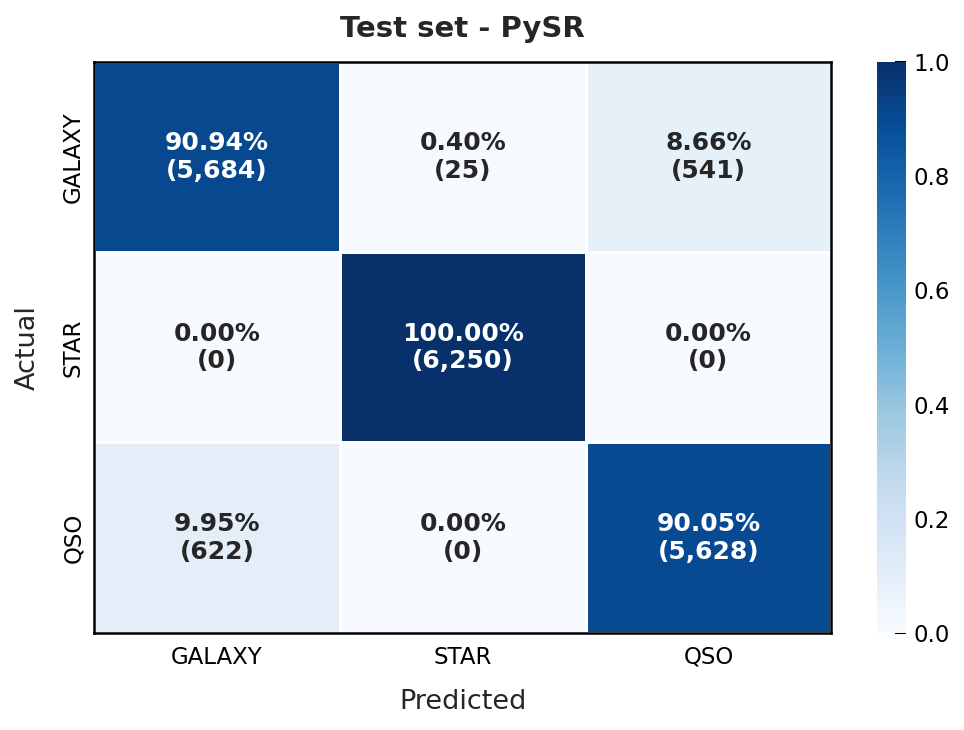

In [19]:
mean_cm = np.mean(fold_cms, axis=0)
cm_test = cm_test_norm

def _pct_annot(M_norm):
    return np.array([[f'{100*v:.2f}%' for v in row] for row in M_norm])

def _pct_count_annot(M_norm, M_count):
    return np.array([
        [f'{100*M_norm[i, j]:.2f}%' + chr(10) + f'({int(M_count[i, j]):,})'
         for j in range(M_norm.shape[1])]
        for i in range(M_norm.shape[0])
    ])

# --- CV mean (row-normalized fractions, no raw counts available) ---
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
sns.heatmap(mean_cm, annot=_pct_annot(mean_cm), fmt='', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            cbar=True, vmin=0, vmax=1,
            annot_kws={'size': 14, 'weight': 'bold'},
            linewidths=0.6, linecolor='white')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual',    labelpad=10)
ax.set_title('5-fold CV average - PySR', fontweight='bold', pad=12)
plt.setp(ax.get_yticklabels(), rotation=90, ha='center', va='center')
ax.tick_params(axis='y', pad=10)
ax.tick_params(axis='x', pad=6)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrix_cv.png')
plt.show()

# --- TEST (percentage on top, count in brackets) ---
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
sns.heatmap(cm_test, annot=_pct_count_annot(cm_test, cm_test_raw),
            fmt='', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            cbar=True, vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'},
            linewidths=0.6, linecolor='white')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual',    labelpad=10)
ax.set_title('Test set - PySR', fontweight='bold', pad=12)
plt.setp(ax.get_yticklabels(), rotation=90, ha='center', va='center')
ax.tick_params(axis='y', pad=10)
ax.tick_params(axis='x', pad=6)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrix_test.png')
plt.show()


## Step 12d — Macro F1 landscape over `(t₁, t₂)` on `val_cv`

2-D map of accuracy as both thresholds vary on a 40×40 grid in `[P₅, P₉₅]²` of `val_cv` scores. Only the valid half-plane ($t_1 < t_2$) is computed; the other half is left blank. The white star marks the calibrated `(t₁, t₂)`.


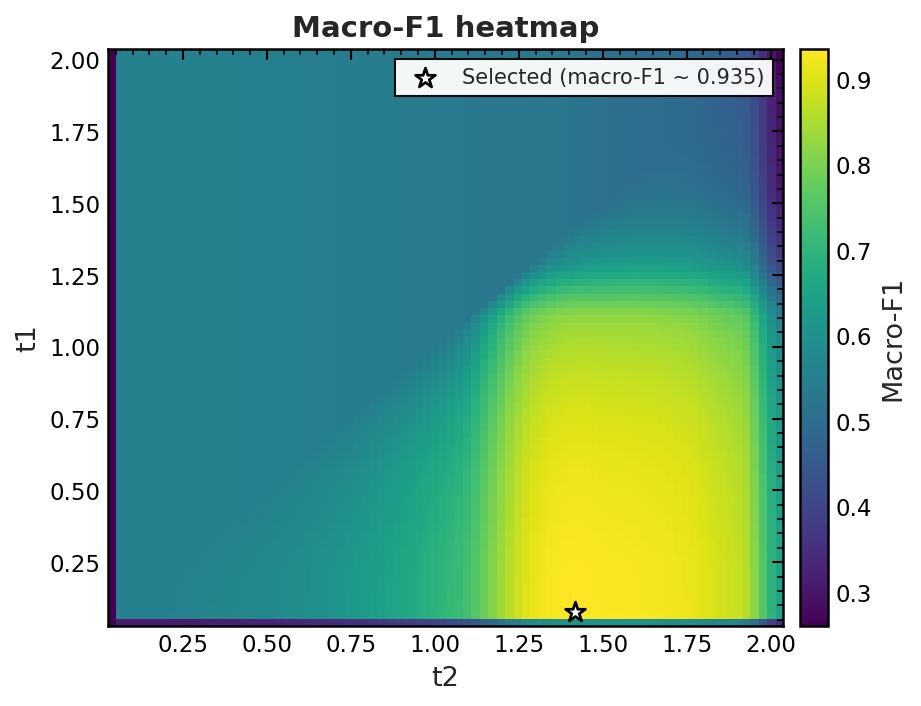

In [20]:
s_val_chk = score_fn(X_val_cv.ravel())

# --- Compute macro-F1 at the chosen (t1_mean, t2_mean) on val_cv ---
y_pred_at_means = classify_scores(s_val_chk, t1_mean, t2_mean)
f1_calib = f1_score(y_val_cv, y_pred_at_means, average='macro')

lo, hi = np.percentile(s_val_chk, [5, 95])
G = 80
ts = np.linspace(lo, hi, G)

F = np.zeros((G, G))
for i, t1 in enumerate(ts):
    for j, t2 in enumerate(ts):
        F[i, j] = f1_score(y_val_cv,
                           classify_scores(s_val_chk, t1, t2),
                           average='macro')

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
im = ax.imshow(F, origin='lower',
               extent=(ts.min(), ts.max(), ts.min(), ts.max()),
               aspect='auto', cmap='viridis',
               vmin=F.min(), vmax=F.max())
ax.scatter([t2_mean], [t1_mean], s=100, color='white',
           marker='*', edgecolor='black', linewidth=1.3, zorder=5,
           label=f'Selected (macro-F1 ~ {f1_calib:.3f})')
ax.set_xlabel('t2'); ax.set_ylabel('t1')
ax.set_title('Macro-F1 heatmap')
fig.colorbar(im, ax=ax, pad=0.02).set_label('Macro-F1')
ax.legend(loc='upper right', fontsize=10, frameon=True)
fig.savefig(RESULTS_DIR / 'macro_f1_heatmap.png')
plt.show()


## Step 12e — Error analysis on TEST and CV data

Two panels:

- **Left (log-y).** Stacked histograms of correctly classified objects
  (grey) and misclassified ones (red) across $z$.
- **Right.** Binned error rate
  $z \mapsto \mathbb{E}[\mathbb{1}_{y \ne \hat y}\mid z]$.

The right-panel peak typically sits near $z \approx 1$, where galaxy and QSO populations physically overlap. This is an information-theoretic floor for a 1-D classifier — not a defect of the discovered equation.


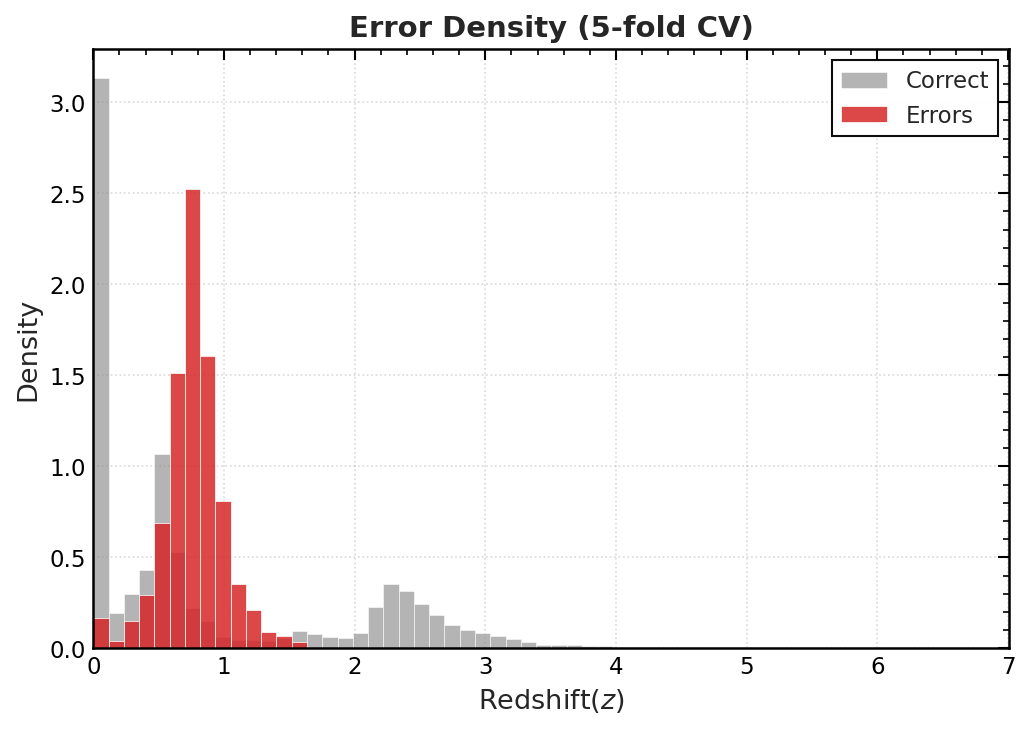

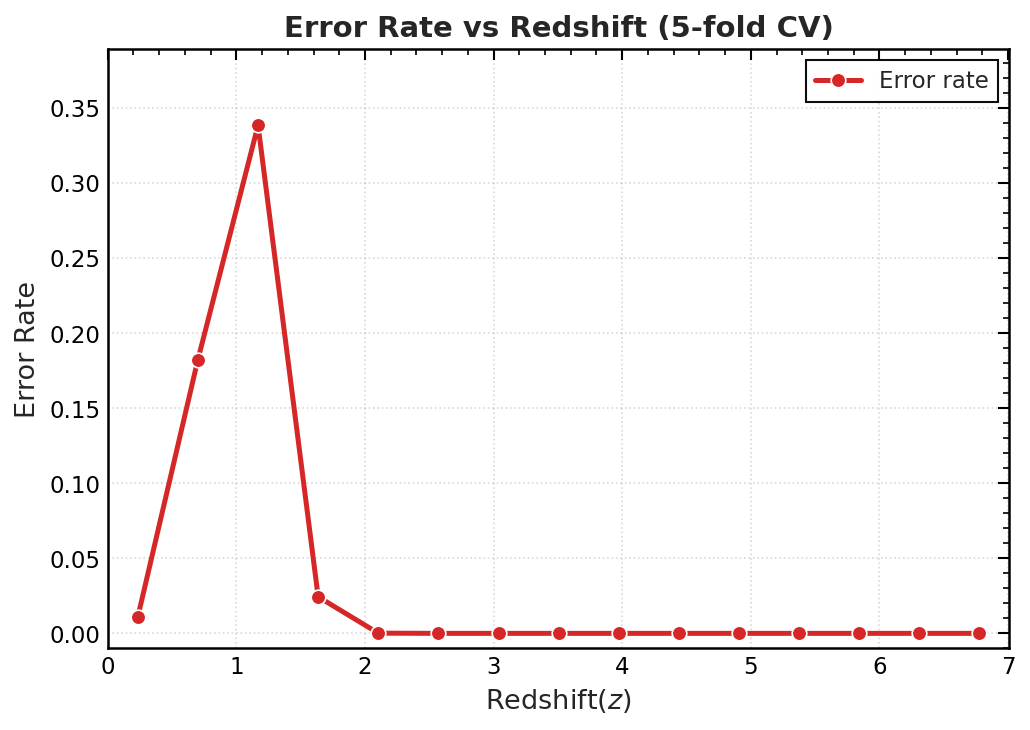

In [21]:
# Pool every fold's held-out predictions: one prediction per val_cv row.
z_cv      = np.concatenate([z  for z, _, _ in fold_predictions])
y_cv_true = np.concatenate([yt for _, yt, _ in fold_predictions])
y_cv_pred = np.concatenate([yp for _, _, yp in fold_predictions])

errors_cv = y_cv_pred != y_cv_true

# Full redshift range (paper convention)
zmax_cv          = float(np.quantile(z_cv, PLOT_Z_QUANTILE))
bins_density_cv  = np.linspace(0.0, zmax_cv, PLOT_N_BINS_DENSITY + 1)
bins_rate_cv     = np.linspace(0.0, zmax_cv, PLOT_N_BINS_RATE + 1)
bcent_rate_cv    = 0.5 * (bins_rate_cv[:-1] + bins_rate_cv[1:])

err_rate_cv, n_cv = binned_error_rate_paper(
    z_cv, errors_cv, bins_rate_cv, min_count=1, zero_fill=True)

# ---- Figure 1: redshift density of correct vs error predictions ----------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.hist(z_cv[~errors_cv], bins=bins_density_cv, density=True,
        alpha=0.65, color='0.55', edgecolor='white', linewidth=0.4,
        label='Correct')
ax.hist(z_cv[errors_cv],  bins=bins_density_cv, density=True,
        alpha=0.85, color='#d62728', edgecolor='white', linewidth=0.4,
        label='Errors')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_cv)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Density')
ax.set_title('Error Density (5-fold CV)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_density_val_cv.png', dpi=200)
plt.show()

# ---- Figure 2: per-bin error rate, coarse bins, marker-line, zero-fill ----
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.plot(bcent_rate_cv, err_rate_cv, color='#d62728', linewidth=2.4,
        marker='o', markersize=7, markerfacecolor='#d62728',
        markeredgecolor='white', markeredgewidth=0.8,
        label='Error rate', zorder=5)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_cv); ax.set_ylim(-0.01, max(0.05, np.nanmax(err_rate_cv) * 1.15))
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Error Rate')
ax.set_title('Error Rate vs Redshift (5-fold CV)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_rate_val_cv.png', dpi=200)
plt.show()


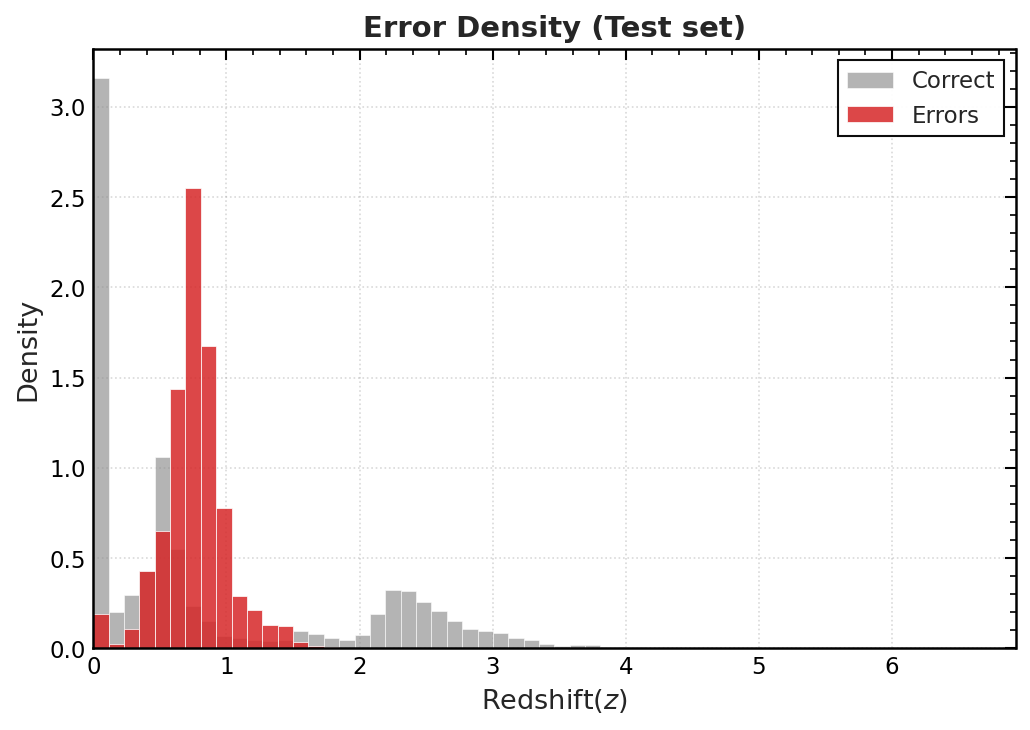

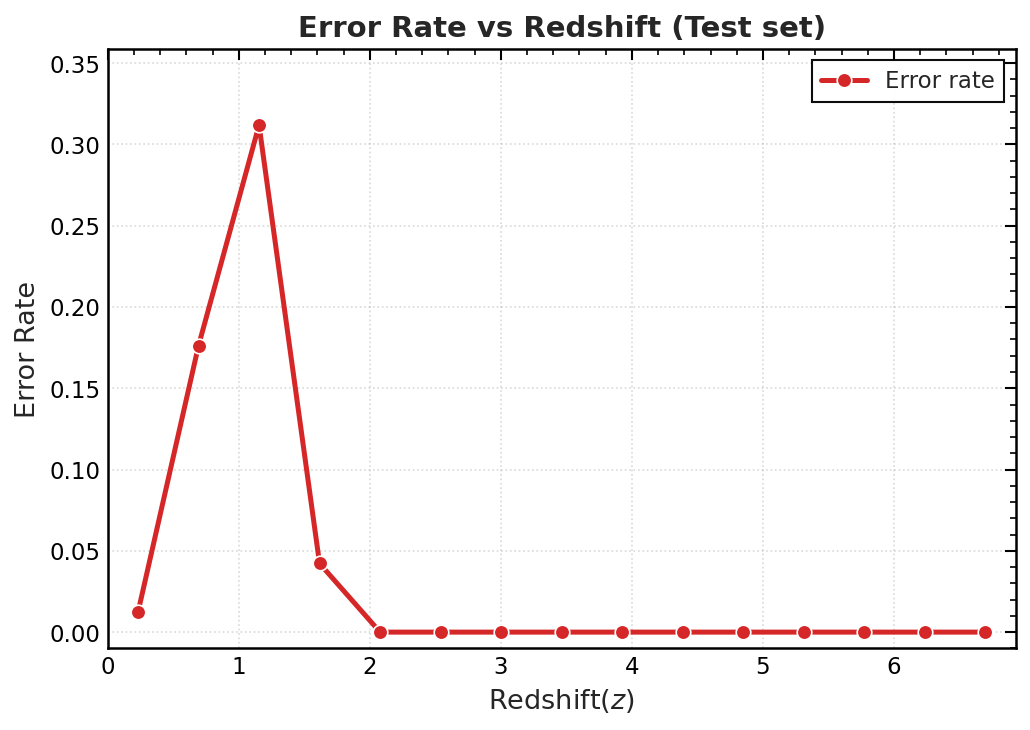

In [22]:
errors_t = y_pred != y_test

zmax_t          = float(np.quantile(z_test, PLOT_Z_QUANTILE))
bins_density_t  = np.linspace(0.0, zmax_t, PLOT_N_BINS_DENSITY + 1)
bins_rate_t     = np.linspace(0.0, zmax_t, PLOT_N_BINS_RATE + 1)
bcent_rate_t    = 0.5 * (bins_rate_t[:-1] + bins_rate_t[1:])

err_rate_t, n_t = binned_error_rate_paper(
    z_test, errors_t, bins_rate_t, min_count=1, zero_fill=True)

# ---- Figure 1: redshift density of correct vs error predictions ----------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.hist(z_test[~errors_t], bins=bins_density_t, density=True,
        alpha=0.65, color='0.55', edgecolor='white', linewidth=0.4,
        label='Correct')
ax.hist(z_test[errors_t],  bins=bins_density_t, density=True,
        alpha=0.85, color='#d62728', edgecolor='white', linewidth=0.4,
        label='Errors')
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_t)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Density')
ax.set_title('Error Density (Test set)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_density_test.png', dpi=300)
plt.show()

# ---- Figure 2: per-bin error rate -----------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.plot(bcent_rate_t, err_rate_t, color='#d62728', linewidth=2.4,
        marker='o', markersize=7, markerfacecolor='#d62728',
        markeredgecolor='white', markeredgewidth=0.8,
        label='Error rate', zorder=5)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_t); ax.set_ylim(-0.01, max(0.05, np.nanmax(err_rate_t) * 1.15))
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Error Rate')
ax.set_title('Error Rate vs Redshift (Test set)', fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'error_rate_test.png', dpi=300)
plt.show()


## Step 12f — Recall vs. redshift

Per-class recall in fine $z$-bins, with shaded $\pm 1\sigma$ bands from the 5 CV folds:

- **Linear-$z$** (clipped to $z \le 2.5$) — shows the galaxy plateau and
  the galaxy → QSO crossover near $z \approx 1$ at high resolution.
- **Log-$z$** — needed to resolve the stellar locus, which lives at
  $z \in [10^{-5},\ 10^{-3}]$ and would otherwise collapse into a single
  pixel on the linear axis.

A thin std band is the test we're after — it says the result is stable across folds, not riding on a lucky split.


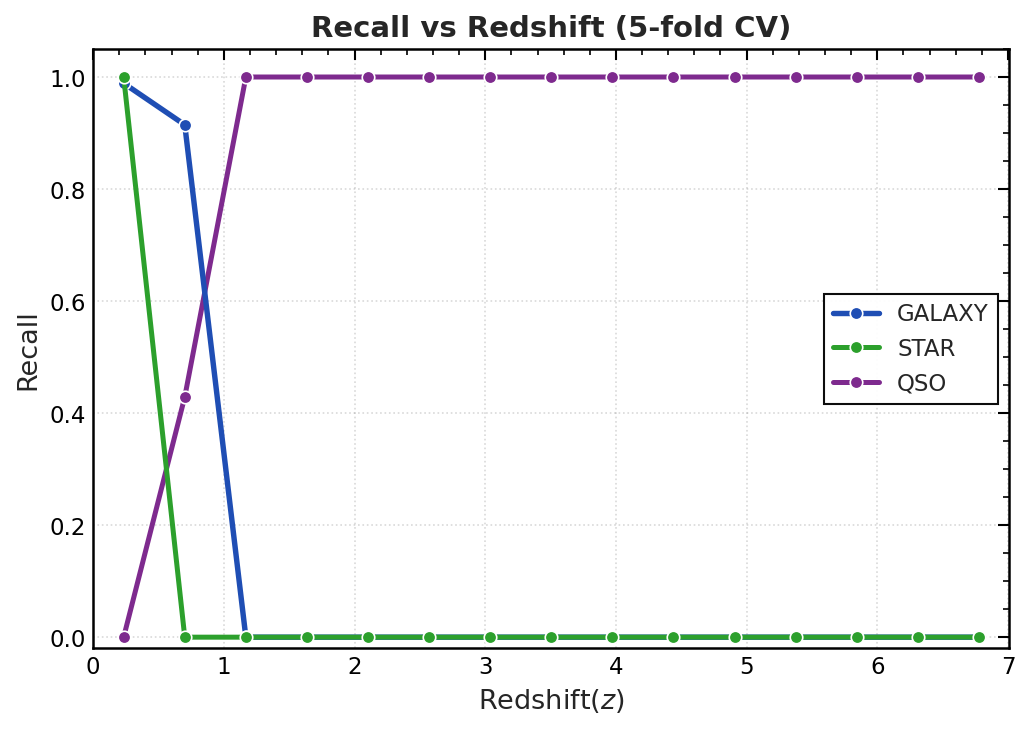

In [23]:
# CV recall vs redshift — paper Figure 12 style: per-fold computation,
# mean +/- 1 sigma across the 5 CV folds. Narrow band where the model is
# stable; widens only at bins where folds genuinely disagree.
z_cv_all = np.concatenate([p[0] for p in fold_predictions])
zmax_cv  = float(np.quantile(z_cv_all, PLOT_Z_QUANTILE))
bins_rec_cv  = np.linspace(0.0, zmax_cv, PLOT_N_BINS_RATE + 1)
bcent_rec_cv = 0.5 * (bins_rec_cv[:-1] + bins_rec_cv[1:])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    cls_id = LABEL_TO_ORD[name]
    per_fold = []
    for z_fold, yt_fold, yp_fold in fold_predictions:
        rec, _ = binned_class_recall_fold_aware(
            z_fold, yt_fold, yp_fold, cls_id, bins_rec_cv, min_count=1)
        per_fold.append(rec)
    mean, std = paper_recall_band(per_fold)

    st = PAPER_CLASS_STYLE[name]
    ax.fill_between(bcent_rec_cv,
                    np.clip(mean - std, 0, 1),
                    np.clip(mean + std, 0, 1),
                    color=st['color'], alpha=0.20, linewidth=0,
                    zorder=st['order'])
    ax.plot(bcent_rec_cv, mean,
            color=st['color'], linewidth=st['lw'],
            marker='o', markersize=6,
            markerfacecolor=st['color'], markeredgecolor='white',
            markeredgewidth=0.8,
            label=name, zorder=st['order'] + 5)

for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_cv); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Recall')
ax.set_title('Recall vs Redshift (5-fold CV)',
             fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='center right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'recall_vs_redshift_val_cv.png', dpi=200)
plt.show()


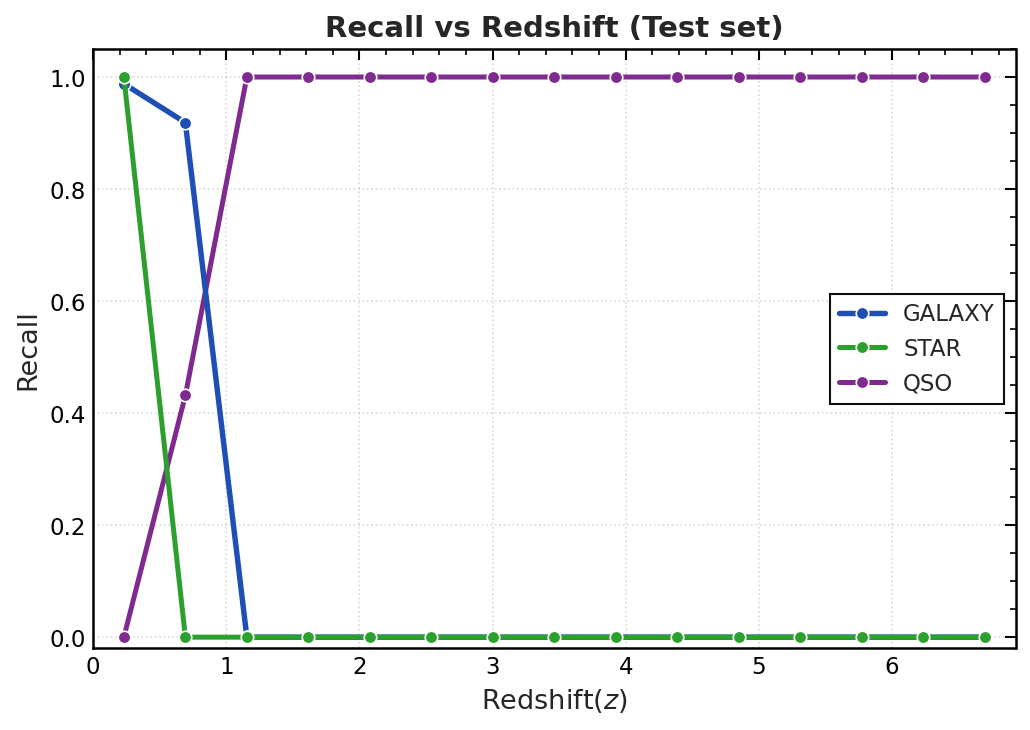

In [24]:
# TEST recall vs redshift — paper-style band built from the 5 CV-fold
# threshold variants. The 5 (t1, t2) pairs are tightly clustered so the
# band is narrow, matching the paper's "Fig. 12" appearance for stable
# classifiers.
zmax_t      = float(np.quantile(z_test, PLOT_Z_QUANTILE))
bins_rec_t  = np.linspace(0.0, zmax_t, PLOT_N_BINS_RATE + 1)
bcent_rec_t = 0.5 * (bins_rec_t[:-1] + bins_rec_t[1:])

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    cls_id = LABEL_TO_ORD[name]
    per_variant = []
    for _, _r in cv_df.iterrows():
        _yp = classify_scores(s_test, float(_r['t1']), float(_r['t2']))
        rec, _ = binned_class_recall_fold_aware(
            z_test, y_test, _yp, cls_id, bins_rec_t, min_count=1)
        per_variant.append(rec)
    mean, std = paper_recall_band(per_variant)

    st = PAPER_CLASS_STYLE[name]
    ax.fill_between(bcent_rec_t,
                    np.clip(mean - std, 0, 1),
                    np.clip(mean + std, 0, 1),
                    color=st['color'], alpha=0.20, linewidth=0,
                    zorder=st['order'])
    ax.plot(bcent_rec_t, mean,
            color=st['color'], linewidth=st['lw'],
            marker='o', markersize=6,
            markerfacecolor=st['color'], markeredgecolor='white',
            markeredgewidth=0.8,
            label=name, zorder=st['order'] + 5)

for sp in ax.spines.values():
    sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.2)
ax.set_xlim(0, zmax_t); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Redshift($z$)'); ax.set_ylabel('Recall')
ax.set_title('Recall vs Redshift (Test set)',
             fontweight='bold')
ax.grid(True, alpha=0.30, linestyle=':')
ax.legend(loc='center right', frameon=True)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'recall_vs_redshift_test.png', dpi=200)
plt.show()


BIC-selected equation : s(z) = 2.4550219 - (1.4099945 / (x0 + 0.58053213))
CV-mean thresholds    : t1 = 0.0780,  t2 = 1.4188


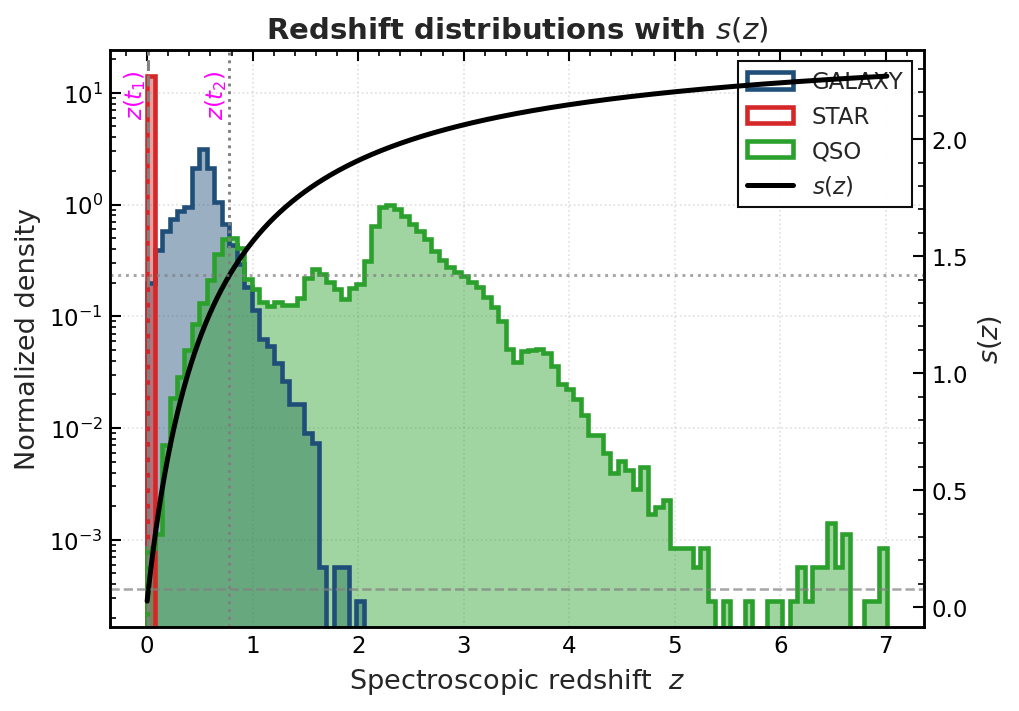

In [25]:
# Per-class redshift distributions with the BIC-selected s(z) overlaid.
# Uses score_fn (Step 8) and t1_mean, t2_mean (Step 9).

print(f'BIC-selected equation : s(z) = {best_equation_str}')
print(f'CV-mean thresholds    : t1 = {t1_mean:.4f},  t2 = {t2_mean:.4f}')

zmax   = float(df['redshift'].max())
z_bins = np.linspace(0.0, zmax, 100)
z_grid = np.linspace(0.0, zmax, 1000)
s_grid = score_fn(z_grid)

# Project t1, t2 back onto the z-axis (defensive sort: monotonic interp)
order    = np.argsort(s_grid)
s_sorted = s_grid[order]
z_sorted = z_grid[order]
z_t1 = float(np.interp(t1_mean, s_sorted, z_sorted)) if (s_sorted.min() <= t1_mean <= s_sorted.max()) else None
z_t2 = float(np.interp(t2_mean, s_sorted, z_sorted)) if (s_sorted.min() <= t2_mean <= s_sorted.max()) else None

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = df.loc[df['class'] == name, 'redshift']
    ax.hist(sub, bins=z_bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=z_bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.set_yscale('log')
ax.set_xlabel('Spectroscopic redshift  $z$')
ax.set_ylabel('Normalized density')
ax.set_title('Redshift distributions with $s(z)$')
ax.grid(True, alpha=0.25, linestyle=':')

ax_r = ax.twinx()
ax_r.plot(z_grid, s_grid, linewidth=2.4, color='black', label='$s(z)$')
ax_r.set_ylabel('$s(z)$')
ax_r.axhline(t1_mean, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax_r.axhline(t2_mean, color='gray', linestyle=':',  linewidth=1.4, alpha=0.7)

for z_t, lbl, ls in [(z_t1, '$z(t_1)$', '--'), (z_t2, '$z(t_2)$', ':')]:
    if z_t is not None:
        ax.axvline(z_t, color='gray', linestyle=ls, linewidth=1.4)
        ax.text(z_t, ax.get_ylim()[1] / 1.5, lbl, rotation=90,
                va='top', ha='right', color='magenta')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')

fig.savefig(RESULTS_DIR / 'redshift_distribution_with_sz.png')
plt.show()

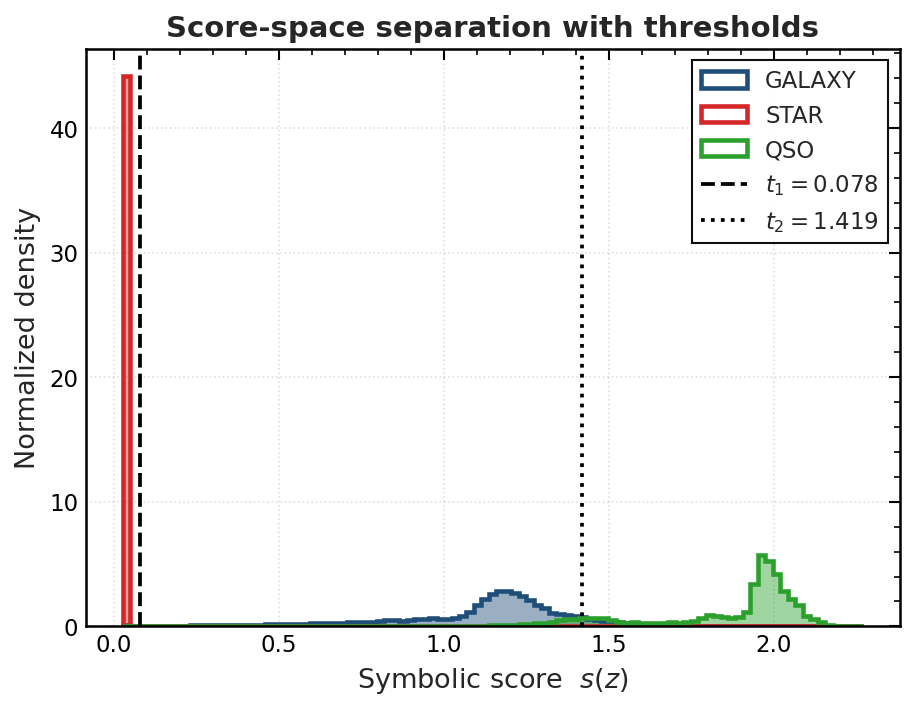

In [26]:
# Score-space (s) per-class histograms with the locked-in thresholds.
# Uses score_fn (Step 8) and t1_mean, t2_mean (Step 9).

s_all  = score_fn(df['redshift'].to_numpy())
s_bins = np.linspace(float(s_all.min()), float(s_all.max()), 100)

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
for name in CLASSES:
    col = PALETTE[name]['color']
    sub = s_all[df['class'].values == name]
    ax.hist(sub, bins=s_bins, density=True, histtype='stepfilled',
            alpha=0.45, color=col)
    ax.hist(sub, bins=s_bins, density=True, histtype='step',
            linewidth=2.2, color=col, label=name)
ax.axvline(t1_mean, color='black', linestyle='--', linewidth=1.8,
           label=f'$t_1 = {t1_mean:.3f}$')
ax.axvline(t2_mean, color='black', linestyle=':',  linewidth=1.8,
           label=f'$t_2 = {t2_mean:.3f}$')
ax.set_xlabel('Symbolic score  $s(z)$')
ax.set_ylabel('Normalized density')
ax.set_title('Score-space separation with thresholds')
ax.grid(True, alpha=0.25, linestyle=':')
ax.legend(loc='upper right')

fig.savefig(RESULTS_DIR / 'score_distribution_with_thresholds.png')
plt.show()
